In [1]:
import os
from dotenv import load_dotenv
load_dotenv('/Users/saturnine/echoes/.env', override=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# dark cinematic style — echoes aesthetic
plt.rcParams.update({
    'figure.facecolor': '#0a0a0a',
    'axes.facecolor': '#111111',
    'axes.edgecolor': '#333333',
    'axes.labelcolor': '#e8e8e8',
    'text.color': '#e8e8e8',
    'xtick.color': '#888888',
    'ytick.color': '#888888',
    'grid.color': '#222222',
    'grid.alpha': 0.5,
    'font.family': 'sans-serif',
    'figure.dpi': 150,
})

ACCENT  = '#8b5cf6'  # violet
ACCENT2 = '#1D9E75'  # teal
ACCENT3 = '#F0997B'  # coral
MUTED   = '#444444'

print("✓ Libraries loaded")
print("✓ Style set")

✓ Libraries loaded
✓ Style set


In [2]:
from utils.lastfm import build_user_profile, get_artist_tags, get_similar_artists

USERNAME = "thesaturnineeee"

print("Fetching full profile... (this takes ~30 seconds)")
profile = build_user_profile(USERNAME)

# unpack
info        = profile["info"]
top_artists = profile["top_artists"]
top_tracks  = profile["top_tracks"]
recent      = profile["recent"]

print(f"\n✓ User: {info['username']}")
print(f"✓ Total scrobbles: {info['playcount']:,}")
print(f"✓ Top artists fetched: {len(top_artists)}")
print(f"✓ Top tracks fetched: {len(top_tracks)}")
print(f"✓ Recent tracks fetched: {len(recent)}")
print(f"✓ Date range: {recent['datetime'].min()} → {recent['datetime'].max()}")

Fetching full profile... (this takes ~30 seconds)
Fetching profile for thesaturnineeee...

✓ User: thesaturnineeee
✓ Total scrobbles: 57,045
✓ Top artists fetched: 20
✓ Top tracks fetched: 50
✓ Recent tracks fetched: 200
✓ Date range: 2026-03-19 04:18:39 → 2026-03-26 02:26:44


In [5]:
import requests
import time

def get_full_history(username, target=5000):
    api_key = os.getenv("LASTFM_API_KEY")
    all_tracks = []
    page = 1
    page_size = 200
    
    print(f"Fetching history for {username}...")
    
    while len(all_tracks) < target:
        try:
            params = {
                "method":   "user.getrecenttracks",
                "user":     username,
                "api_key":  api_key,
                "format":   "json",
                "limit":    page_size,
                "page":     page,
            }
            
            response = requests.get(
                "https://ws.audioscrobbler.com/2.0/",
                params=params
            )
            data = response.json()
            
            tracks = data["recenttracks"]["track"]
            total_pages = int(data["recenttracks"]["@attr"]["totalPages"])
            total_scrobbles = int(data["recenttracks"]["@attr"]["total"])
            
            if page == 1:
                print(f"  total scrobbles on Last.fm: {total_scrobbles:,}")
                print(f"  total pages available: {total_pages:,}")
            
            for track in tracks:
                # skip now playing track
                if "@attr" in track and track["@attr"].get("nowplaying"):
                    continue
                    
                all_tracks.append({
                    "title":     track["name"],
                    "artist":    track["artist"]["#text"],
                    "album":     track["album"]["#text"],
                    "timestamp": track.get("date", {}).get("uts", None),
                })
            
            print(f"  page {page}/{min(total_pages, target//page_size)} → {len(all_tracks):,} tracks")
            
            if page >= total_pages:
                print("  reached last page!")
                break
                
            page += 1
            time.sleep(0.25)
            
        except Exception as e:
            print(f"  error on page {page}: {e}")
            break
    
    df = pd.DataFrame(all_tracks)
    
    if not df.empty:
        df = df.drop_duplicates()
        df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
        df["datetime"]  = pd.to_datetime(df["timestamp"], unit="s")
        df["hour"]      = df["datetime"].dt.hour
        df["day"]       = df["datetime"].dt.day_name()
        df["day_num"]   = df["datetime"].dt.dayofweek
        df["month"]     = df["datetime"].dt.to_period("M").astype(str)
        df["year"]      = df["datetime"].dt.year
        df["date"]      = df["datetime"].dt.date
        df = df.dropna(subset=["datetime"])
        df = df.sort_values("datetime", ascending=False).reset_index(drop=True)
    
    print(f"\n✓ Total tracks fetched: {len(df):,}")
    print(f"✓ Date range: {df['datetime'].min()} → {df['datetime'].max()}")
    print(f"✓ Unique artists: {df['artist'].nunique()}")
    print(f"✓ Unique tracks: {df['title'].nunique()}")
    
    return df

history = get_full_history(USERNAME, target=5000)

Fetching history for thesaturnineeee...
  total scrobbles on Last.fm: 57,045
  total pages available: 286
  page 1/25 → 200 tracks
  page 2/25 → 400 tracks
  page 3/25 → 600 tracks
  page 4/25 → 800 tracks
  page 5/25 → 1,000 tracks
  page 6/25 → 1,200 tracks
  page 7/25 → 1,400 tracks
  page 8/25 → 1,600 tracks
  page 9/25 → 1,800 tracks
  page 10/25 → 2,000 tracks
  page 11/25 → 2,200 tracks
  page 12/25 → 2,400 tracks
  page 13/25 → 2,600 tracks
  page 14/25 → 2,800 tracks
  page 15/25 → 3,000 tracks
  page 16/25 → 3,200 tracks
  page 17/25 → 3,400 tracks
  page 18/25 → 3,600 tracks
  page 19/25 → 3,800 tracks
  page 20/25 → 4,000 tracks
  page 21/25 → 4,200 tracks
  page 22/25 → 4,400 tracks
  page 23/25 → 4,600 tracks
  page 24/25 → 4,800 tracks
  page 25/25 → 5,000 tracks

✓ Total tracks fetched: 4,974
✓ Date range: 2025-08-11 05:20:03 → 2026-03-26 02:26:44
✓ Unique artists: 223
✓ Unique tracks: 700


In [6]:
import os

# create data directory if not exists
os.makedirs('/Users/saturnine/echoes/data', exist_ok=True)

# save history
history.to_csv('/Users/saturnine/echoes/data/history.csv', index=False)
top_artists.to_csv('/Users/saturnine/echoes/data/top_artists.csv', index=False)
top_tracks.to_csv('/Users/saturnine/echoes/data/top_tracks.csv', index=False)

print(f"✓ history.csv saved — {len(history):,} rows")
print(f"✓ top_artists.csv saved — {len(top_artists)} rows")
print(f"✓ top_tracks.csv saved — {len(top_tracks)} rows")

✓ history.csv saved — 4,974 rows
✓ top_artists.csv saved — 20 rows
✓ top_tracks.csv saved — 50 rows


In [7]:
print("=== DATA QUALITY REPORT ===\n")

print("HISTORY:")
print(f"  shape:         {history.shape}")
print(f"  null values:\n{history.isnull().sum()}")
print(f"\n  dtypes:\n{history.dtypes}")

print("\nTOP ARTISTS:")
print(f"  shape:         {top_artists.shape}")
print(f"  null values:   {top_artists.isnull().sum().sum()}")

print("\nTOP TRACKS:")
print(f"  shape:         {top_tracks.shape}")
print(f"  null values:   {top_tracks.isnull().sum().sum()}")

print("\n=== BASIC STATS ===\n")
print(f"Total scrobbles fetched:  {len(history):,}")
print(f"Date range:               {history['datetime'].min().date()} → {history['datetime'].max().date()}")
print(f"Days covered:             {(history['datetime'].max() - history['datetime'].min()).days}")
print(f"Avg plays per day:        {len(history) / (history['datetime'].max() - history['datetime'].min()).days:.1f}")
print(f"Unique artists:           {history['artist'].nunique()}")
print(f"Unique tracks:            {history['title'].nunique()}")
print(f"Unique albums:            {history['album'].nunique()}")
print(f"Most played artist:       {history['artist'].value_counts().index[0]} ({history['artist'].value_counts().iloc[0]:,} plays)")
print(f"Most played track:        {history['title'].value_counts().index[0]} ({history['title'].value_counts().iloc[0]:,} plays)")

=== DATA QUALITY REPORT ===

HISTORY:
  shape:         (4974, 11)
  null values:
title        0
artist       0
album        0
timestamp    0
datetime     0
hour         0
day          0
day_num      0
month        0
year         0
date         0
dtype: int64

  dtypes:
title                object
artist               object
album                object
timestamp             int64
datetime     datetime64[ns]
hour                  int32
day                  object
day_num               int32
month                object
year                  int32
date                 object
dtype: object

TOP ARTISTS:
  shape:         (20, 4)
  null values:   0

TOP TRACKS:
  shape:         (50, 4)
  null values:   0

=== BASIC STATS ===

Total scrobbles fetched:  4,974
Date range:               2025-08-11 → 2026-03-26
Days covered:             226
Avg plays per day:        22.0
Unique artists:           223
Unique tracks:            700
Unique albums:            470
Most played artist:       Pritam (595 

In [8]:
from utils.lastfm import get_artist_tags
import time

# get all unique artists from history
all_artists = history['artist'].value_counts()
# only artists with 10+ plays — enough signal
significant_artists = all_artists[all_artists >= 10].index.tolist()

print(f"Total unique artists: {history['artist'].nunique()}")
print(f"Artists with 10+ plays: {len(significant_artists)}")
print(f"Fetching tags for each... (~{len(significant_artists) * 0.3:.0f} seconds)\n")

artist_tags = {}
failed = []

for i, artist in enumerate(significant_artists):
    tags = get_artist_tags(artist, limit=15)
    artist_tags[artist] = tags
    
    if tags:
        print(f"  [{i+1}/{len(significant_artists)}] {artist}: {tags[:5]}")
    else:
        failed.append(artist)
        print(f"  [{i+1}/{len(significant_artists)}] {artist}: no tags found")
    
    time.sleep(0.2)

print(f"\n✓ Tags fetched for {len(artist_tags) - len(failed)} artists")
print(f"✗ No tags found for {len(failed)} artists: {failed}")

Total unique artists: 223
Artists with 10+ plays: 63
Fetching tags for each... (~19 seconds)

  [1/63] Pritam: ['bollywood', 'hindi', 'all', 'indian', 'soundtrack']
  [2/63] Shankar-Ehsaan-Loy: ['bollywood', 'hindi', 'indian', 'soundtrack', 'india']
  [3/63] A.R. Rahman: ['soundtrack', 'indian', 'bollywood', 'hindi', 'a r rahman']
  [4/63] Atif Aslam: ['hindi', 'pakistani rock', 'pakistani', 'pakistan', 'soft rock']
  [5/63] Vishal-Shekhar: ['bollywood', 'hindi', 'soundtrack', 'indian', 'india']
  [6/63] Siddharth Pandit: no tags found
  [7/63] Arijit Singh: ['hindi', 'bollywood', 'soundtrack', 'indian', 'india']
  [8/63] DIGV: no tags found
  [9/63] Ana Rehman: no tags found
  [10/63] Sachin-Jigar: ['all', 'bollywood', 'indian', 'india', 'mumbai']
  [11/63] Prithvi Gandharv: no tags found
  [12/63] Sai Abhyankkar: ['hindi', 'indian', 'goat abhyankkar', "can't spell isai without sai"]
  [13/63] Amit Sharma: no tags found
  [14/63] Lana Del Rey: ['indie', 'female vocalists', 'indie pop'

In [9]:
import json
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

# save raw tags to disk
os.makedirs('/Users/saturnine/echoes/data', exist_ok=True)
with open('/Users/saturnine/echoes/data/artist_tags.json', 'w') as f:
    json.dump(artist_tags, f, indent=2)
print("✓ artist_tags.json saved")

# remove artists with no tags
artist_tags_clean = {k: v for k, v in artist_tags.items() if v}
print(f"✓ Artists with tags: {len(artist_tags_clean)}")

# join tags into a single string per artist
artist_tag_strings = {
    artist: " ".join(tags) 
    for artist, tags in artist_tags_clean.items()
}

# build TF-IDF matrix
artists_list = list(artist_tag_strings.keys())
tag_corpus   = list(artist_tag_strings.values())

tfidf = TfidfVectorizer(
    max_features=100,
    ngram_range=(1, 2),   # unigrams + bigrams e.g. "indie rock"
    min_df=1,
)
tfidf_matrix = tfidf.fit_transform(tag_corpus)
tfidf_dense  = normalize(tfidf_matrix.toarray())

print(f"\n✓ TF-IDF matrix shape: {tfidf_dense.shape}")
print(f"  → {tfidf_dense.shape[0]} artists × {tfidf_dense.shape[1]} tag features")

# save to disk
np.save('/Users/saturnine/echoes/data/tfidf_matrix.npy', tfidf_dense)
with open('/Users/saturnine/echoes/data/artists_list.json', 'w') as f:
    json.dump(artists_list, f)

print("\n✓ Feature matrix saved")
print("\nTop 20 tags in your listening universe:")
feature_names = tfidf.get_feature_names_out()
tag_sums = tfidf_dense.sum(axis=0)
top_tags_idx = tag_sums.argsort()[::-1][:20]
for idx in top_tags_idx:
    print(f"  {feature_names[idx]}: {tag_sums[idx]:.3f}")

✓ artist_tags.json saved
✓ Artists with tags: 57

✓ TF-IDF matrix shape: (57, 100)
  → 57 artists × 100 tag features

✓ Feature matrix saved

Top 20 tags in your listening universe:
  indian: 9.034
  bollywood: 6.817
  india: 6.614
  hindi: 6.410
  all: 4.940
  soundtrack: 4.627
  bollywood hindi: 3.709
  hindi indian: 3.465
  world: 3.424
  desi: 3.307
  pop: 3.303
  indian india: 3.063
  indian hindi: 2.910
  india indian: 2.515
  all indian: 2.491
  rock: 2.354
  composer: 2.332
  indie: 2.290
  hindi bollywood: 2.251
  bollywood indian: 2.244


In [10]:
# tags that carry no meaningful signal
NOISE_TAGS = {
    'all', 'world', 'composer', 'soundtrack', 'india indian',
    'indian india', 'hindi indian', 'bollywood hindi', 'hindi bollywood',
    'bollywood indian', 'indian hindi', 'all indian', 'india'
}

artist_tags_clean2 = {}
for artist, tags in artist_tags_clean.items():
    cleaned = [t for t in tags if t not in NOISE_TAGS]
    if cleaned:
        artist_tags_clean2[artist] = cleaned

# rebuild TF-IDF with clean tags
artists_list2 = list(artist_tags_clean2.keys())
tag_corpus2   = [" ".join(tags) for tags in artist_tags_clean2.values()]

tfidf2 = TfidfVectorizer(
    max_features=100,
    ngram_range=(1, 2),
    min_df=1,
)
tfidf_matrix2 = tfidf2.fit_transform(tag_corpus2)
tfidf_clean   = normalize(tfidf_matrix2.toarray())

print(f"✓ Clean matrix shape: {tfidf_clean.shape}")
print(f"\nTop 20 meaningful tags:")
feature_names2 = tfidf2.get_feature_names_out()
tag_sums2 = tfidf_clean.sum(axis=0)
top_idx = tag_sums2.argsort()[::-1][:20]
for idx in top_idx:
    print(f"  {feature_names2[idx]}: {tag_sums2[idx]:.3f}")

# save clean versions
np.save('/Users/saturnine/echoes/data/tfidf_matrix_clean.npy', tfidf_clean)
with open('/Users/saturnine/echoes/data/artists_list_clean.json', 'w') as f:
    json.dump(artists_list2, f)

print("\n✓ Clean feature matrix saved")

✓ Clean matrix shape: (57, 100)

Top 20 meaningful tags:
  indian: 11.351
  bollywood: 8.244
  hindi: 7.697
  hindi indian: 5.536
  bollywood hindi: 4.789
  indian bollywood: 3.990
  desi: 3.746
  pop: 3.517
  bollywood indian: 3.257
  indian hindi: 3.192
  hindi bollywood: 2.955
  indie: 2.706
  rock: 2.467
  vocalists: 2.258
  alternative: 2.071
  filmi: 2.035
  rahman: 1.954
  fusion: 1.906
  indian fusion: 1.906
  male: 1.838

✓ Clean feature matrix saved


In [11]:
NOISE_TAGS = {
    'all', 'world', 'composer', 'soundtrack', 'india', 'indian',
    'bollywood', 'hindi', 'desi', 'filmi', 'rahman', 'male',
    'vocalists', 'fusion', 'mumbai', 'pakistan', 'canadian',
    'american', 'british', 'goat abhyankkar', 'mondiovision',
    "can't spell isai without sai", 'radio bombay', 'snake',
    'taylor swift', 'a r rahman', 'mohit chauhan', 'karthik',
    'rashid ali', 'roop', 'inde', 'icelandic', 'ofwgkta',
    'bangla', 'kollywood', 'tamil', 'telugu', 'punjabi',
    'punjab', 'urdu', 'bhangra', 'smooth', 'electronica',
}

artist_tags_final = {}
for artist, tags in artist_tags_clean.items():
    cleaned = [t for t in tags if t.lower() not in NOISE_TAGS]
    if cleaned:
        artist_tags_final[artist] = cleaned

# rebuild with unigrams only
artists_final  = list(artist_tags_final.keys())
corpus_final   = [" ".join(tags) for tags in artist_tags_final.values()]

tfidf_final = TfidfVectorizer(
    max_features=80,
    ngram_range=(1, 1),  # unigrams only
    min_df=1,
)
matrix_final = tfidf_final.fit_transform(corpus_final)
matrix_norm  = normalize(matrix_final.toarray())

print(f"✓ Final matrix: {matrix_norm.shape}")
print(f"  → {matrix_norm.shape[0]} artists × {matrix_norm.shape[1]} tag features")

print(f"\nTop 30 meaningful tags in your universe:")
feat_names = tfidf_final.get_feature_names_out()
feat_sums  = matrix_norm.sum(axis=0)
top_idx    = feat_sums.argsort()[::-1][:30]
for idx in top_idx:
    print(f"  {feat_names[idx]}: {feat_sums[idx]:.3f}")

# save final versions
np.save('/Users/saturnine/echoes/data/tfidf_final.npy', matrix_norm)
with open('/Users/saturnine/echoes/data/artists_final.json', 'w') as f:
    json.dump(artists_final, f)
with open('/Users/saturnine/echoes/data/artist_tags_final.json', 'w') as f:
    json.dump(artist_tags_final, f)

print("\n✓ Final matrices saved — ready for EDA and ML")

✓ Final matrix: (48, 80)
  → 48 artists × 80 tag features

Top 30 meaningful tags in your universe:
  pop: 4.905
  vocalists: 3.390
  indian: 3.384
  rock: 3.302
  male: 3.092
  indie: 2.770
  alternative: 2.668
  bollywood: 2.209
  fusion: 2.158
  rnb: 1.726
  hindi: 1.720
  pakistani: 1.708
  music: 1.680
  film: 1.632
  playback: 1.482
  hindie: 1.419
  female: 1.341
  electronic: 1.293
  romantic: 1.287
  melody: 1.245
  classical: 1.214
  vocals: 1.214
  sufi: 1.167
  ambient: 1.162
  hop: 1.140
  bollybolly: 1.091
  soul: 1.084
  pritam: 1.000
  shankar: 1.000
  dance: 1.000

✓ Final matrices saved — ready for EDA and ML


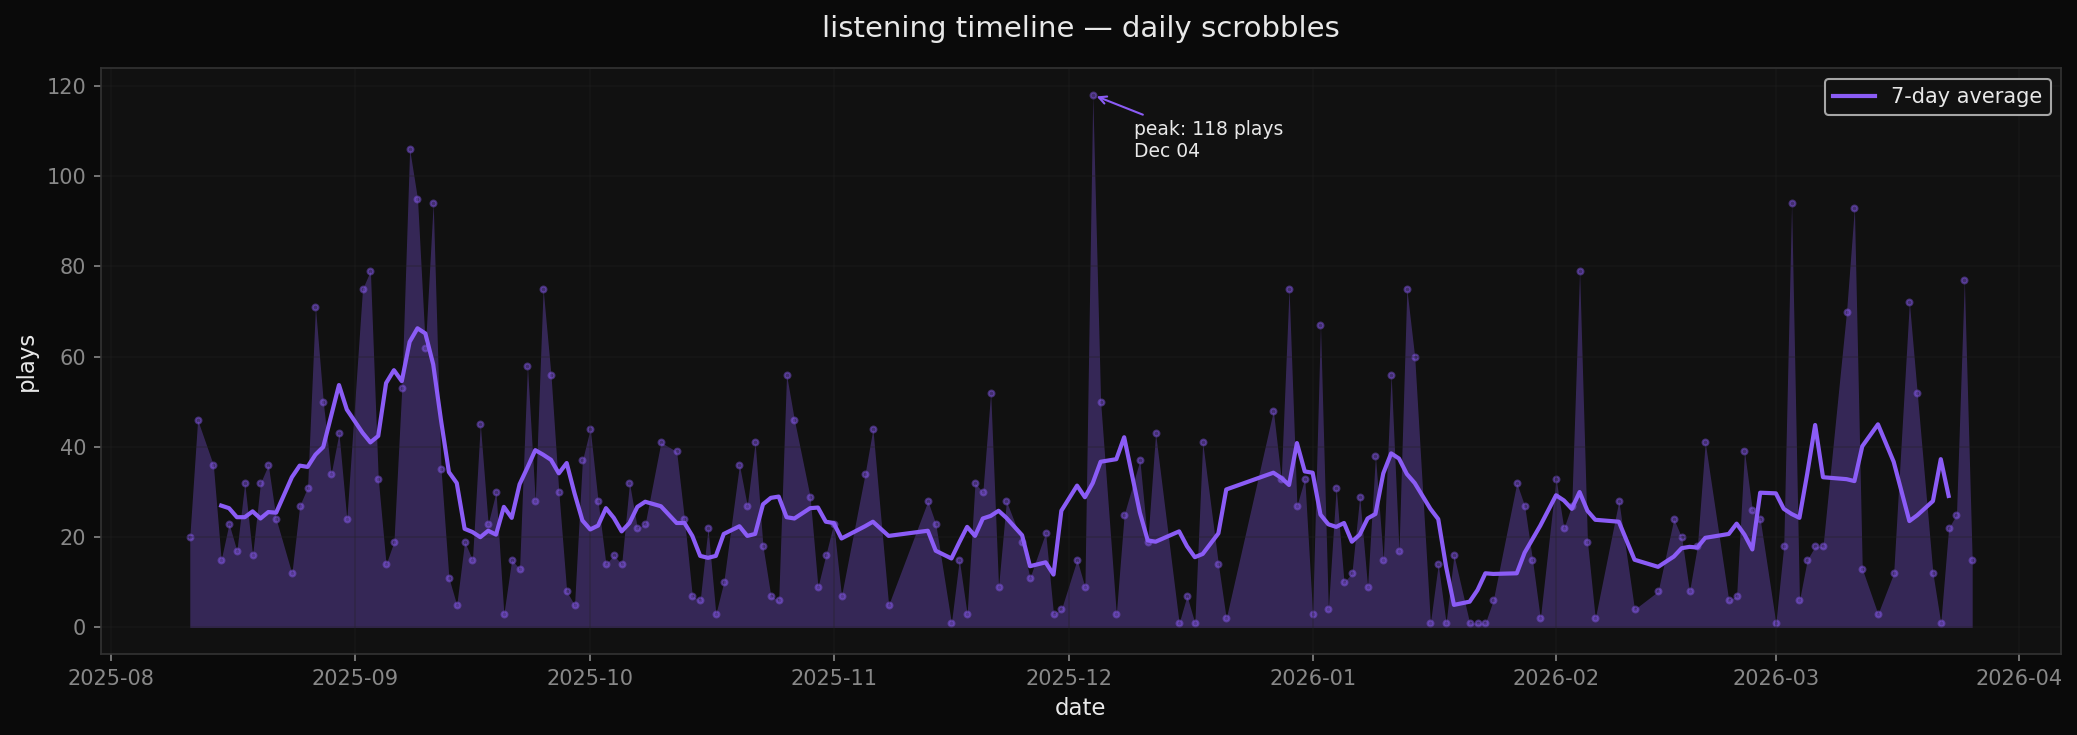

✓ Timeline saved


In [12]:
# ── PART 2: LISTENING BEHAVIOR ANALYSIS ──────────────────────

fig, ax = plt.subplots(figsize=(14, 5))

# daily play counts
daily = history.groupby('date').size().reset_index(name='plays')
daily['date'] = pd.to_datetime(daily['date'])
daily = daily.sort_values('date')

# 7-day rolling average
daily['rolling'] = daily['plays'].rolling(7, center=True).mean()

ax.fill_between(daily['date'], daily['plays'], 
                alpha=0.3, color=ACCENT, linewidth=0)
ax.plot(daily['date'], daily['rolling'], 
        color=ACCENT, linewidth=2, label='7-day average')
ax.scatter(daily['date'], daily['plays'], 
           color=ACCENT, alpha=0.4, s=8)

# find peak day
peak_idx = daily['plays'].idxmax()
peak_date = daily.loc[peak_idx, 'date']
peak_val  = daily.loc[peak_idx, 'plays']
ax.annotate(f'peak: {peak_val} plays\n{peak_date.strftime("%b %d")}',
            xy=(peak_date, peak_val),
            xytext=(20, -30), textcoords='offset points',
            color='#e8e8e8', fontsize=9,
            arrowprops=dict(arrowstyle='->', color=ACCENT))

ax.set_xlabel('date', fontsize=11)
ax.set_ylabel('plays', fontsize=11)
ax.set_title('listening timeline — daily scrobbles', 
             fontsize=14, pad=15, color='#e8e8e8')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/saturnine/echoes/data/viz_timeline.png', 
            dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()
print("✓ Timeline saved")

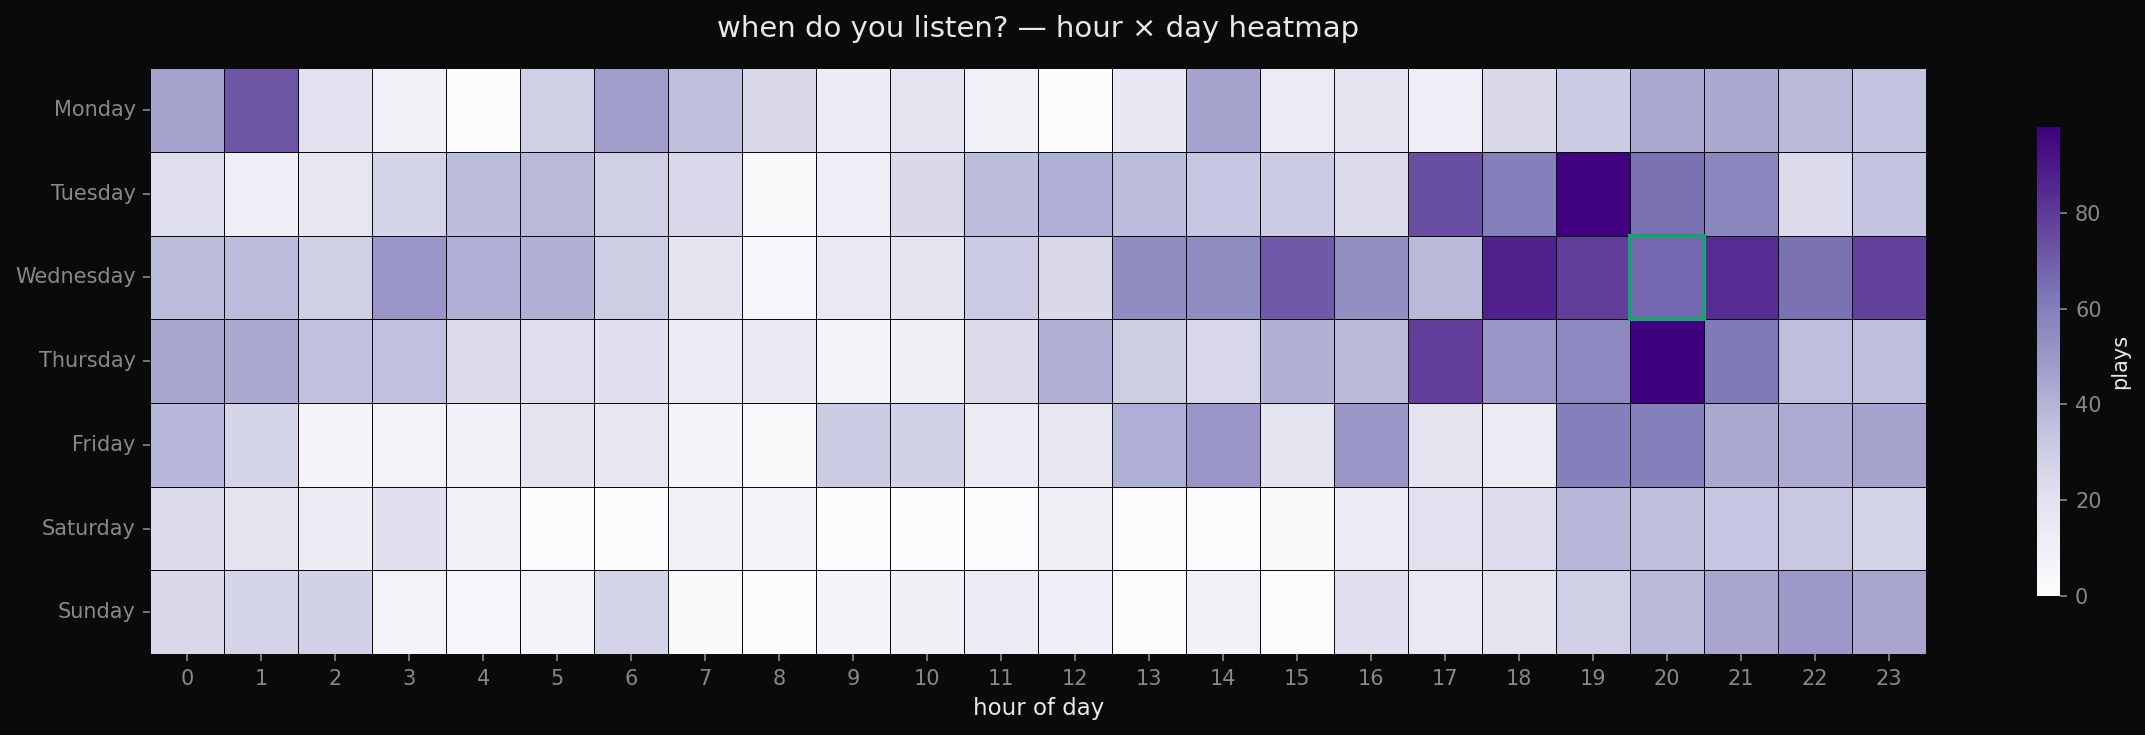

Peak listening hour:  20:00
Peak listening day:   Wednesday

Hour breakdown:
  00:00  ███████████ 238
  01:00  ███████████ 237
  02:00  ███████ 148
  03:00  ████████ 160
  04:00  ██████ 127
  05:00  ███████ 155
  06:00  ████████ 172
  07:00  █████ 112
  08:00  ██ 58
  09:00  ████ 83
  10:00  █████ 113
  11:00  ██████ 131
  12:00  ███████ 148
  13:00  █████████ 181
  14:00  ███████████ 220
  15:00  █████████ 180
  16:00  ███████████ 221
  17:00  ████████████ 257
  18:00  █████████████ 279
  19:00  ███████████████████ 391
  20:00  ████████████████████ 407
  21:00  ██████████████████ 369
  22:00  ██████████████ 287
  23:00  ███████████████ 300


In [13]:
# ── HEATMAP: hour of day × day of week ───────────────────────

pivot = history.groupby(['day_num', 'hour']).size().unstack(fill_value=0)

day_labels = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 
              'Friday', 'Saturday', 'Sunday']
pivot.index = day_labels

fig, ax = plt.subplots(figsize=(16, 5))

sns.heatmap(
    pivot,
    ax=ax,
    cmap='Purples',
    linewidths=0.3,
    linecolor='#0a0a0a',
    annot=False,
    fmt='d',
    cbar_kws={'label': 'plays', 'shrink': 0.8},
)

ax.set_title('when do you listen? — hour × day heatmap', 
             fontsize=14, pad=15, color='#e8e8e8')
ax.set_xlabel('hour of day', fontsize=11)
ax.set_ylabel('')
ax.tick_params(colors='#888888')

# mark peak cell
peak_hour = history['hour'].value_counts().index[0]
peak_day  = history['day_num'].value_counts().index[0]
ax.add_patch(plt.Rectangle(
    (peak_hour, peak_day), 1, 1,
    fill=False, edgecolor=ACCENT2, lw=2, label='peak hour'
))

plt.tight_layout()
plt.savefig('/Users/saturnine/echoes/data/viz_heatmap.png',
            dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

# insights
print(f"Peak listening hour:  {peak_hour}:00")
print(f"Peak listening day:   {day_labels[peak_day]}")
print(f"\nHour breakdown:")
hourly = history['hour'].value_counts().sort_index()
for h, c in hourly.items():
    bar = '█' * (c // 20)
    print(f"  {h:02d}:00  {bar} {c}")

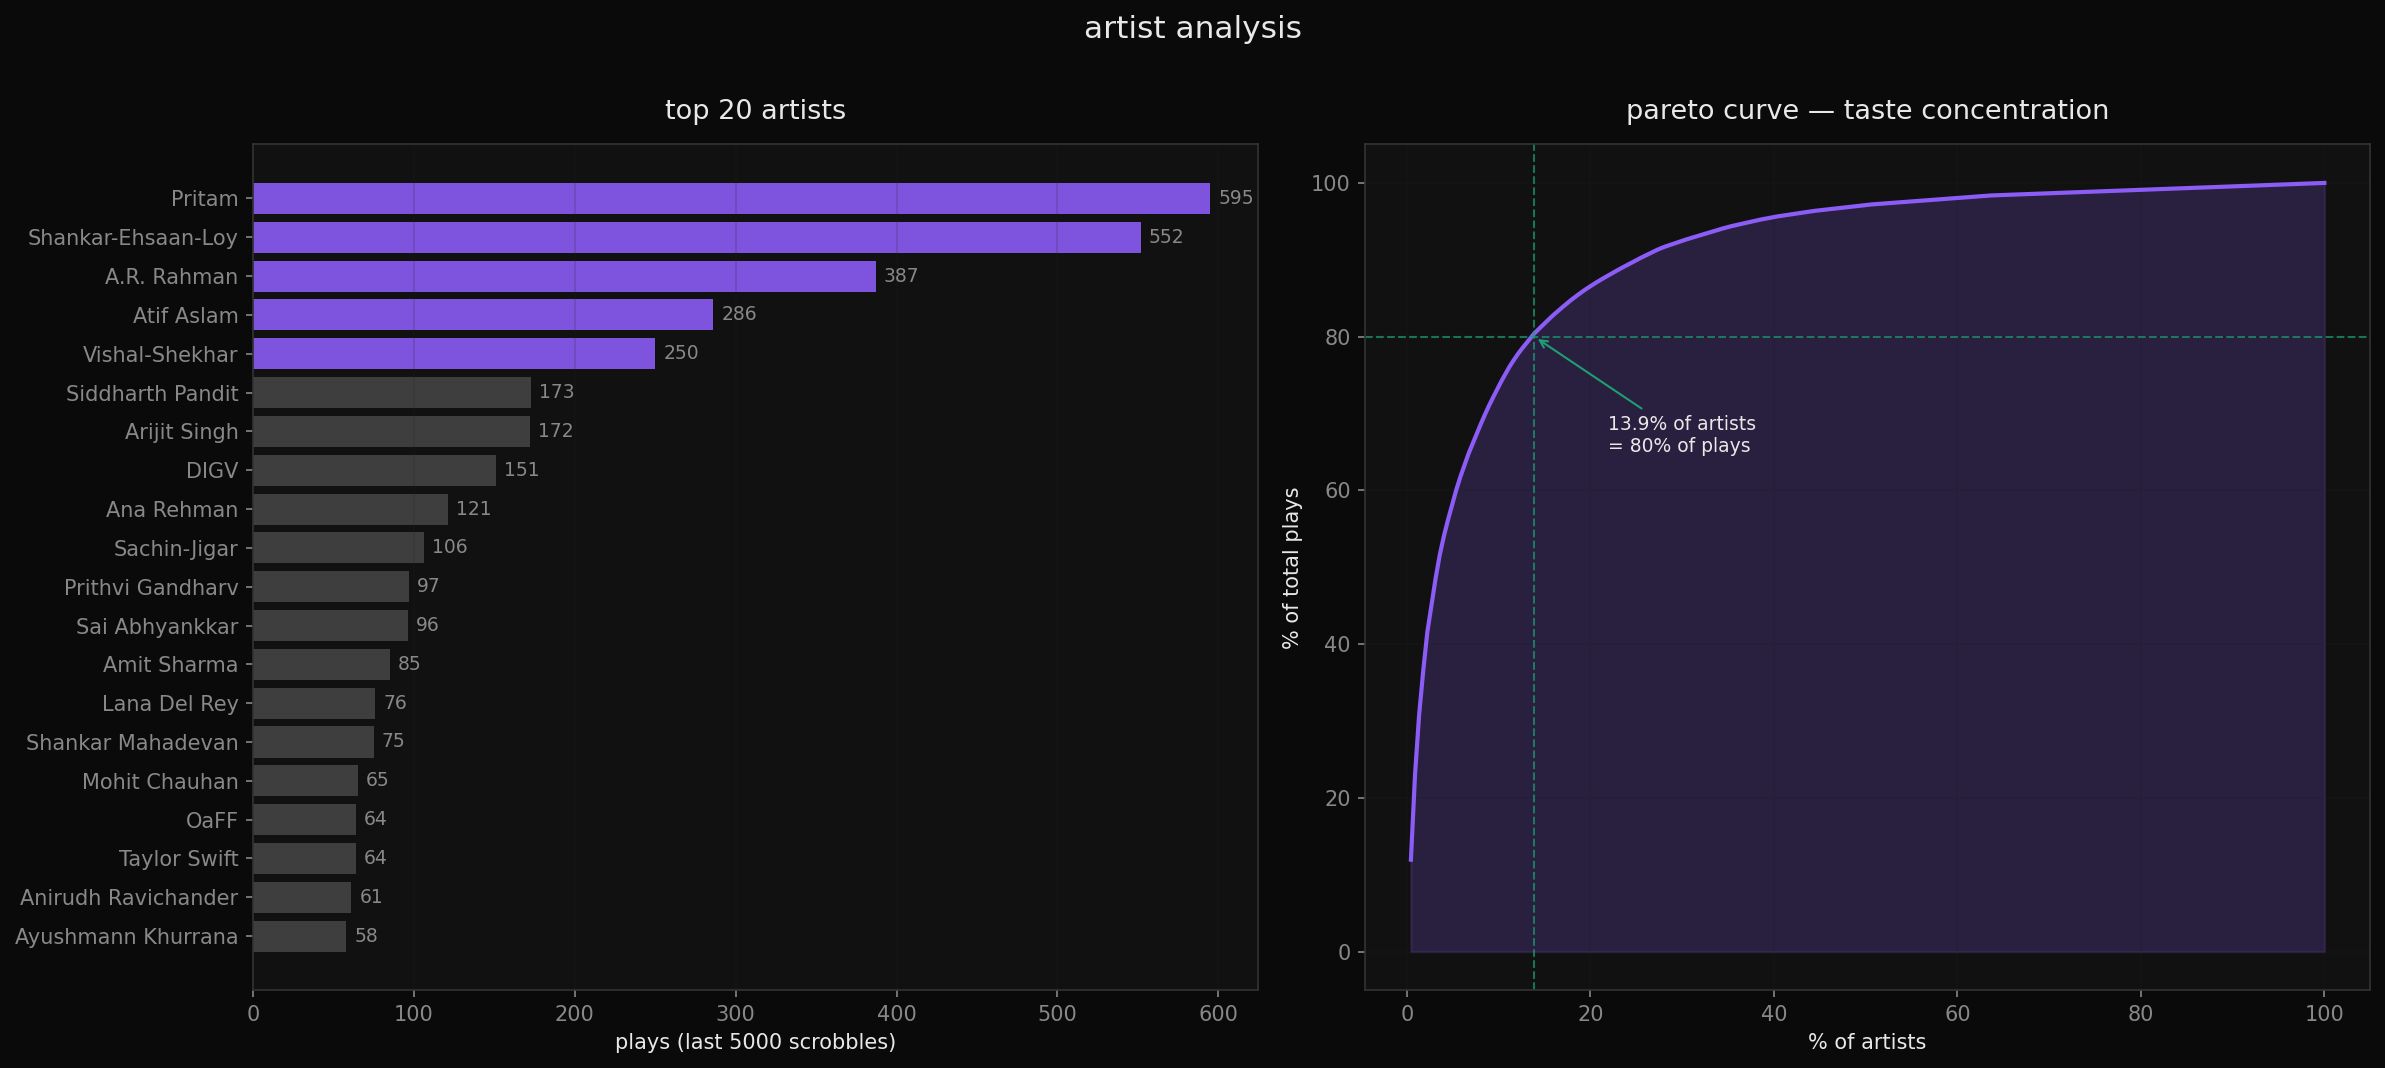


Pareto insight:
  13.9% of your artists = 80% of your plays
  That's 30 artists out of 223

Top 5 artists dominate:
  Top 5 = 41.6% of all plays


In [14]:
# ── PART 3: ARTIST ANALYSIS ──────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── left: top 20 artists bar chart ───────────────────────────
artist_counts = history['artist'].value_counts().head(20)

colors = [ACCENT if i < 5 else '#444444' 
          for i in range(len(artist_counts))]

axes[0].barh(
    range(len(artist_counts)), 
    artist_counts.values,
    color=colors, alpha=0.9
)
axes[0].set_yticks(range(len(artist_counts)))
axes[0].set_yticklabels(artist_counts.index, fontsize=10)
axes[0].invert_yaxis()
axes[0].set_xlabel('plays (last 5000 scrobbles)', fontsize=10)
axes[0].set_title('top 20 artists', fontsize=13, pad=12)
axes[0].grid(True, alpha=0.2, axis='x')

# add value labels
for i, v in enumerate(artist_counts.values):
    axes[0].text(v + 5, i, str(v), va='center', 
                fontsize=9, color='#888888')

# ── right: pareto curve ───────────────────────────────────────
sorted_artists = history['artist'].value_counts()
cumulative_pct = (sorted_artists.cumsum() / sorted_artists.sum() * 100)
artist_pct     = np.arange(1, len(sorted_artists) + 1) / len(sorted_artists) * 100

axes[1].plot(artist_pct, cumulative_pct.values, 
             color=ACCENT, linewidth=2)
axes[1].fill_between(artist_pct, cumulative_pct.values, 
                     alpha=0.2, color=ACCENT)

# mark 80% line
idx_80 = np.argmax(cumulative_pct.values >= 80)
pct_artists_80 = artist_pct[idx_80]
axes[1].axhline(80, color=ACCENT2, linestyle='--', alpha=0.7, linewidth=1)
axes[1].axvline(pct_artists_80, color=ACCENT2, linestyle='--', 
                alpha=0.7, linewidth=1)
axes[1].annotate(
    f'{pct_artists_80:.1f}% of artists\n= 80% of plays',
    xy=(pct_artists_80, 80),
    xytext=(pct_artists_80 + 8, 65),
    color='#e8e8e8', fontsize=9,
    arrowprops=dict(arrowstyle='->', color=ACCENT2)
)

axes[1].set_xlabel('% of artists', fontsize=10)
axes[1].set_ylabel('% of total plays', fontsize=10)
axes[1].set_title('pareto curve — taste concentration', fontsize=13, pad=12)
axes[1].grid(True, alpha=0.2)

plt.suptitle('artist analysis', fontsize=15, y=1.01, color='#e8e8e8')
plt.tight_layout()
plt.savefig('/Users/saturnine/echoes/data/viz_artists.png',
            dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

print(f"\nPareto insight:")
print(f"  {pct_artists_80:.1f}% of your artists = 80% of your plays")
print(f"  That's {idx_80} artists out of {len(sorted_artists)}")
print(f"\nTop 5 artists dominate:")
top5_pct = sorted_artists.head(5).sum() / sorted_artists.sum() * 100
print(f"  Top 5 = {top5_pct:.1f}% of all plays")

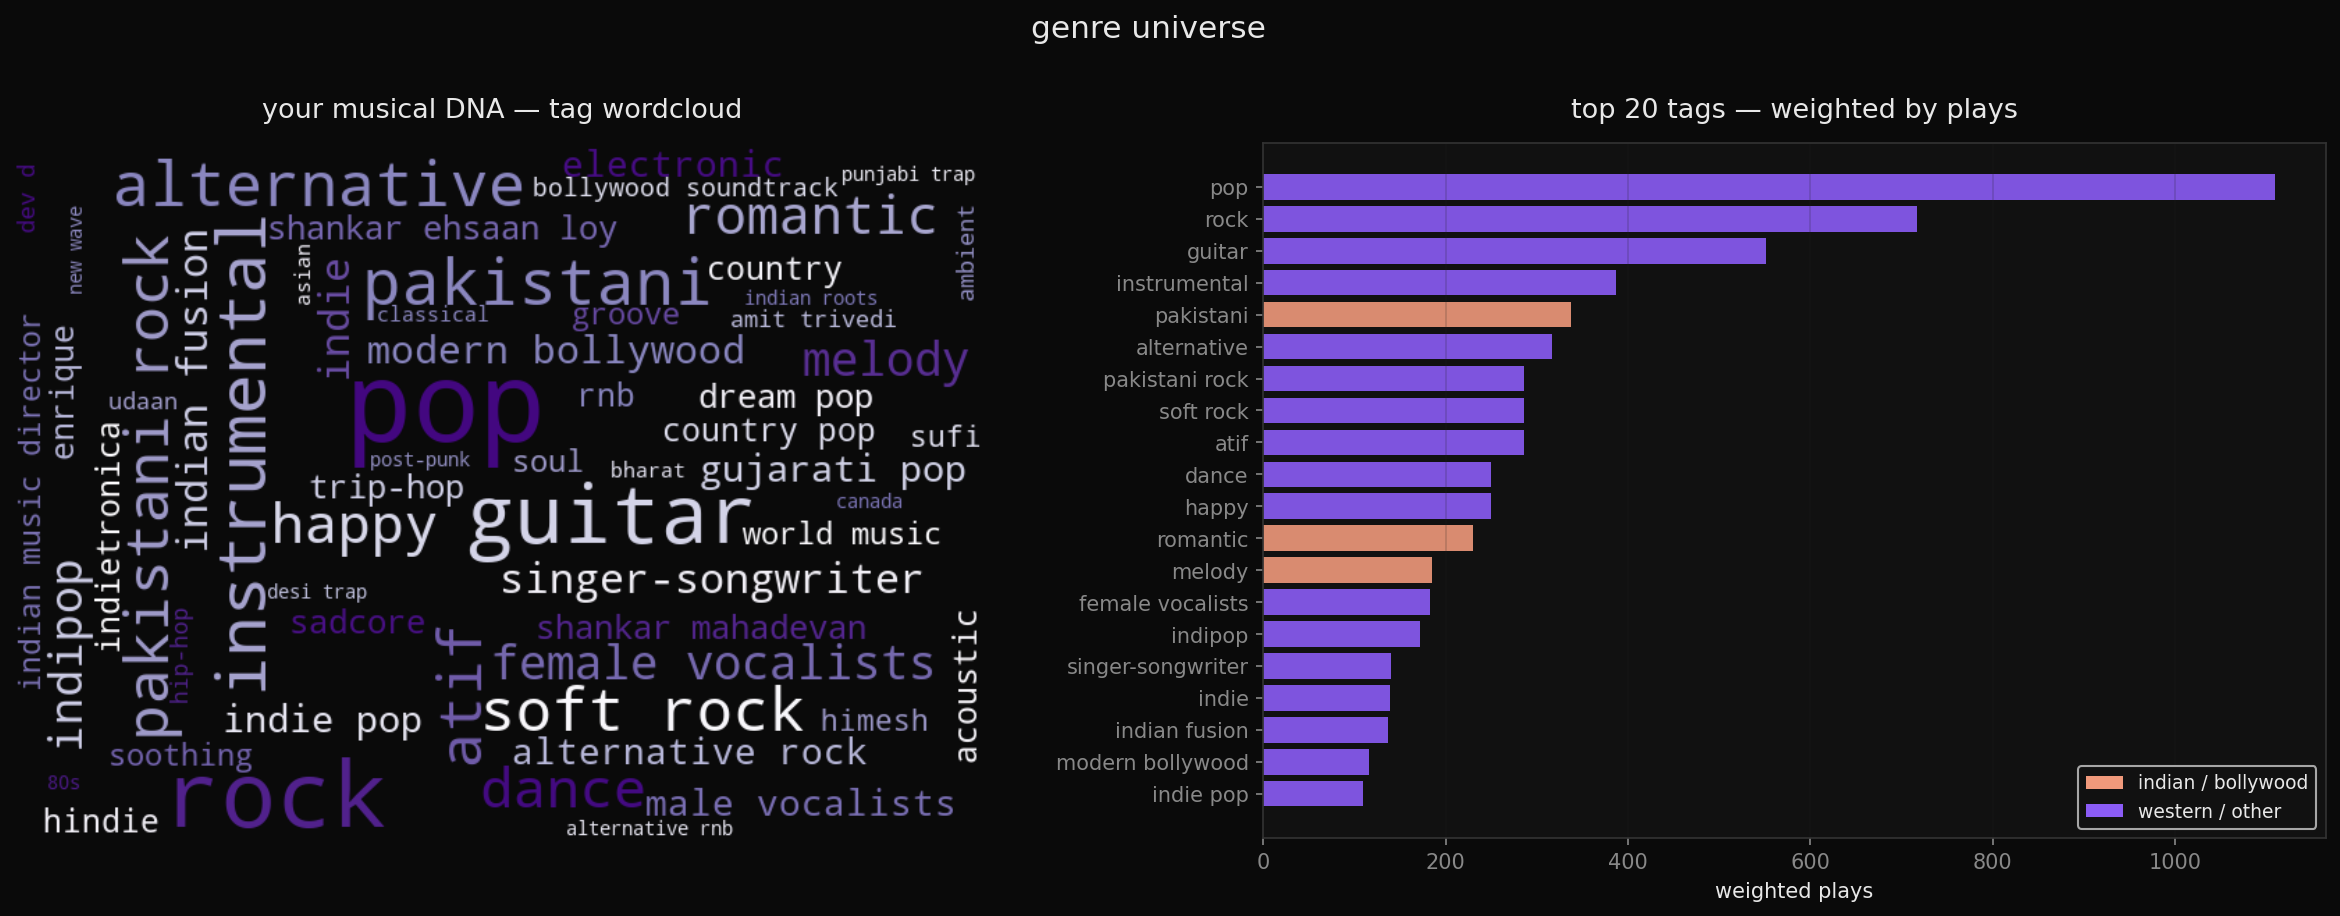


Tag universe summary:
  Total unique tags: 107

Top 10 tags by weighted plays:
  pop                    1110  🎸 western
  rock                    717  🎸 western
  guitar                  552  🎸 western
  instrumental            387  🎸 western
  pakistani               338  🎵 indian
  alternative             317  🎸 western
  pakistani rock          286  🎸 western
  soft rock               286  🎸 western
  atif                    286  🎸 western
  dance                   250  🎸 western


In [15]:
# ── PART 4: GENRE/TAG ANALYSIS ───────────────────────────────

from wordcloud import WordCloud
from collections import Counter

# flatten all tags weighted by artist playcount
tag_weights = Counter()
artist_plays = history['artist'].value_counts().to_dict()

for artist, tags in artist_tags_final.items():
    plays = artist_plays.get(artist, 1)
    for tag in tags:
        tag_weights[tag] += plays

# remove remaining noise
final_noise = {'all', 'music', 'bollybolly', 'pritam', 'shankar',
               'hop', 'male', 'female', 'vocals', 'vocalists'}
tag_weights = {k: v for k, v in tag_weights.items() 
               if k not in final_noise and len(k) > 2}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── left: wordcloud ───────────────────────────────────────────
wc = WordCloud(
    width=700, height=500,
    background_color='#0a0a0a',
    colormap='Purples',
    max_words=60,
    prefer_horizontal=0.8,
    min_font_size=10,
    max_font_size=80,
    collocations=False,
).generate_from_frequencies(tag_weights)

axes[0].imshow(wc, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('your musical DNA — tag wordcloud', 
                  fontsize=13, pad=12)

# ── right: top 20 tags bar ────────────────────────────────────
top_tags = sorted(tag_weights.items(), key=lambda x: x[1], reverse=True)[:20]
tag_names = [t[0] for t in top_tags]
tag_vals  = [t[1] for t in top_tags]

bar_colors = []
bollywood_tags = {'bollywood', 'hindi', 'indian', 'desi', 'sufi', 
                  'filmi', 'playback', 'hindie', 'fusion', 'film',
                  'classical', 'melody', 'romantic', 'pakistani'}
for tag in tag_names:
    if tag in bollywood_tags:
        bar_colors.append(ACCENT3)   # coral = indian/bollywood
    else:
        bar_colors.append(ACCENT)    # violet = western

axes[1].barh(range(len(tag_names)), tag_vals, 
             color=bar_colors, alpha=0.9)
axes[1].set_yticks(range(len(tag_names)))
axes[1].set_yticklabels(tag_names, fontsize=10)
axes[1].invert_yaxis()
axes[1].set_xlabel('weighted plays', fontsize=10)
axes[1].set_title('top 20 tags — weighted by plays', fontsize=13, pad=12)
axes[1].grid(True, alpha=0.2, axis='x')

# legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=ACCENT3, label='indian / bollywood'),
    Patch(facecolor=ACCENT,  label='western / other'),
]
axes[1].legend(handles=legend_elements, fontsize=9, 
               loc='lower right')

plt.suptitle('genre universe', fontsize=15, y=1.01, color='#e8e8e8')
plt.tight_layout()
plt.savefig('/Users/saturnine/echoes/data/viz_genres.png',
            dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

print("\nTag universe summary:")
print(f"  Total unique tags: {len(tag_weights)}")
print(f"\nTop 10 tags by weighted plays:")
for tag, val in top_tags[:10]:
    marker = "🎵 indian" if tag in bollywood_tags else "🎸 western"
    print(f"  {tag:<20} {val:>6}  {marker}")

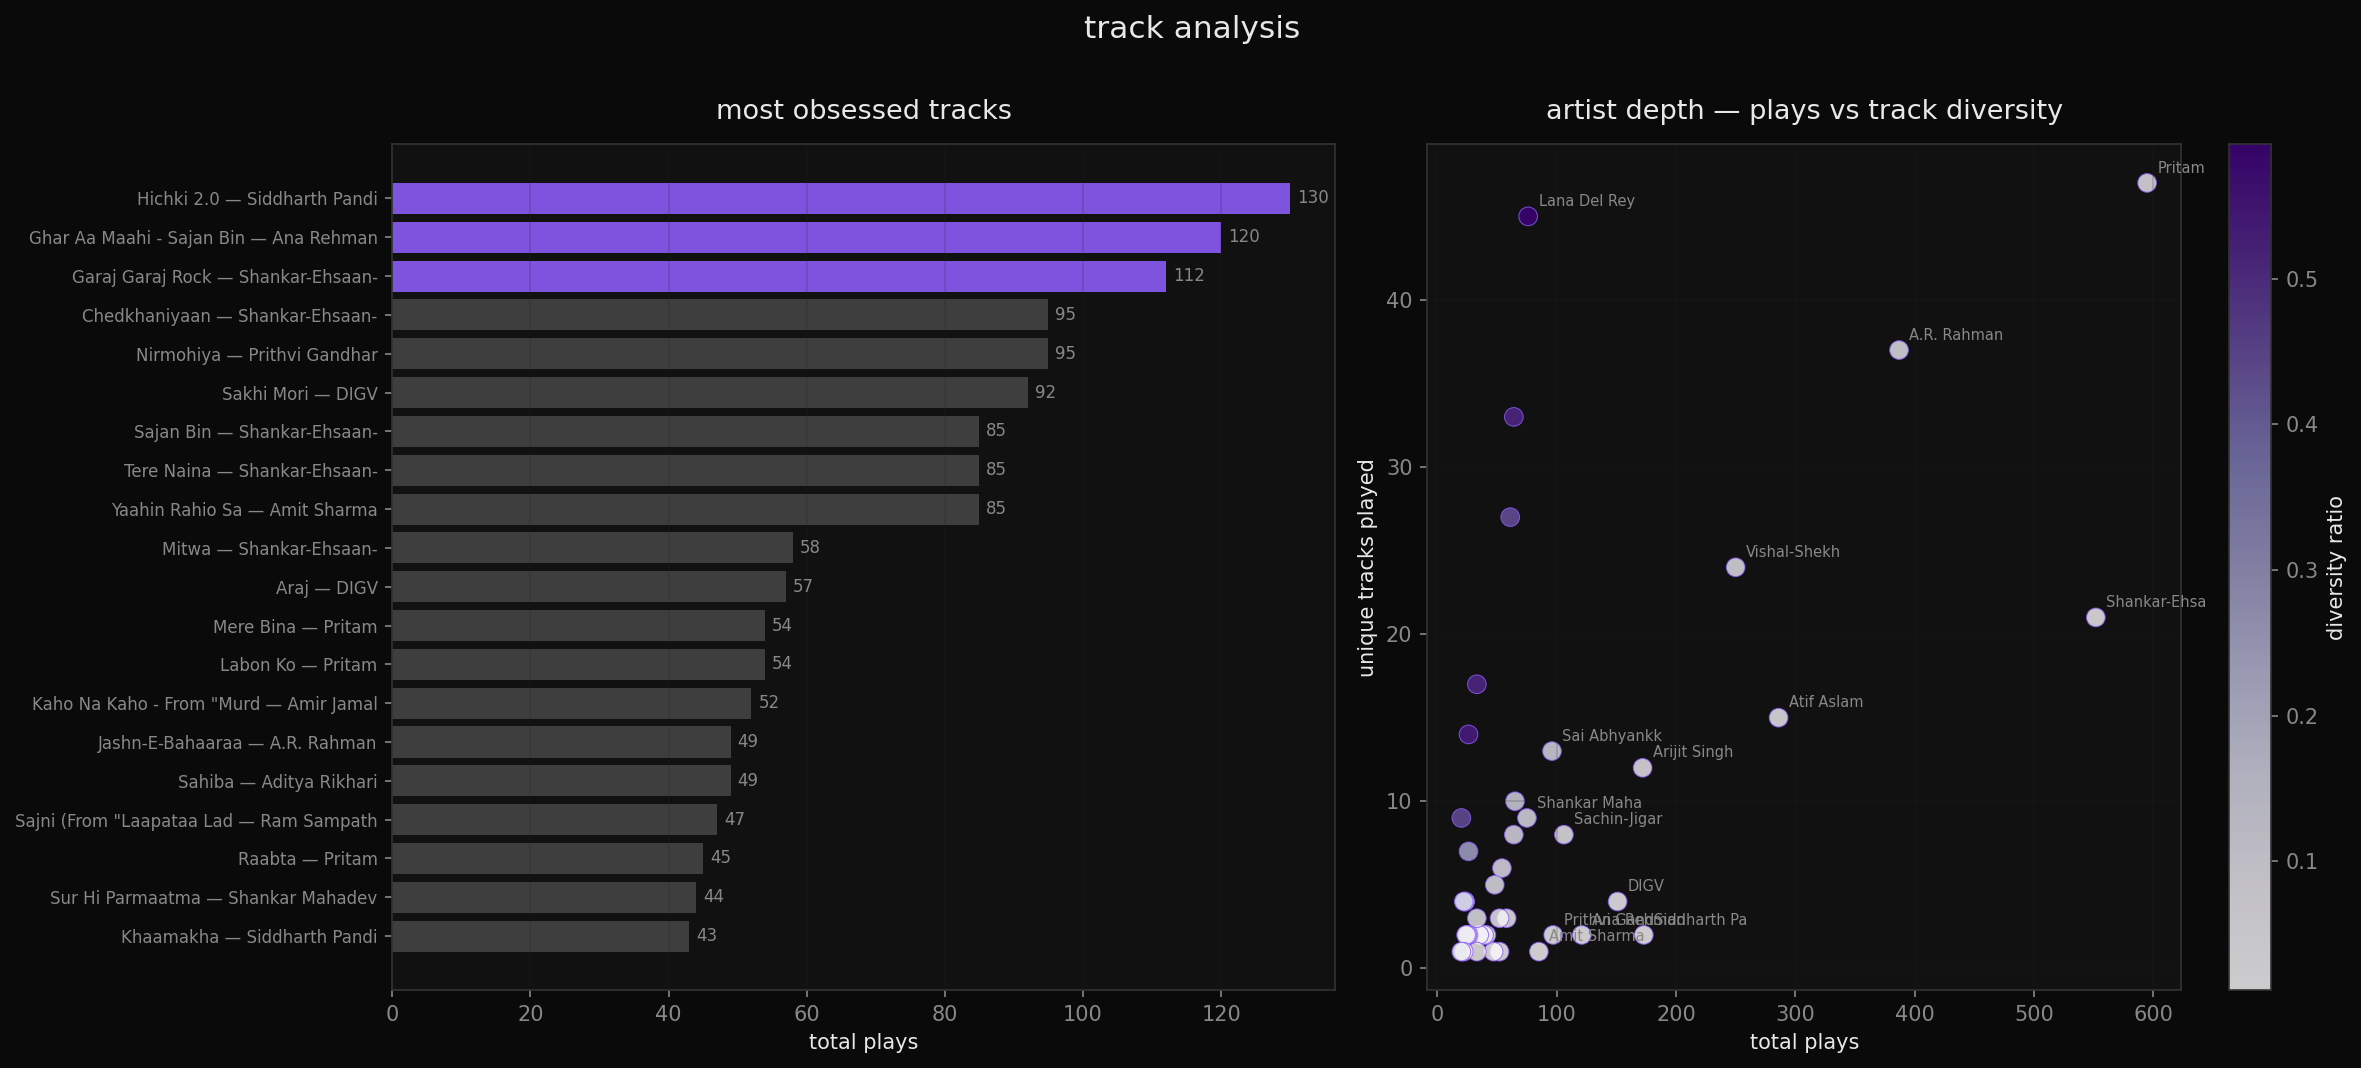

Top 10 most obsessed tracks:
  130x  Hichki 2.0 — Siddharth Pandit
  120x  Ghar Aa Maahi - Sajan Bin Vers — Ana Rehman
  112x  Garaj Garaj Rock — Shankar-Ehsaan-Loy
   95x  Chedkhaniyaan — Shankar-Ehsaan-Loy
   95x  Nirmohiya — Prithvi Gandharv
   92x  Sakhi Mori — DIGV
   85x  Sajan Bin — Shankar-Ehsaan-Loy
   85x  Tere Naina — Shankar-Ehsaan-Loy
   85x  Yaahin Rahio Sa — Amit Sharma
   58x  Mitwa — Shankar-Ehsaan-Loy

Artist depth insights:

Most track-diverse (explorer):
  Lana Del Rey: 45 tracks / 76 plays (0.59)
  S. P. Balasubrahmanyam: 14 tracks / 26 plays (0.54)
  Taylor Swift: 33 tracks / 64 plays (0.52)

Least track-diverse (repeater):
  Siddharth Pandit: 2 tracks / 173 plays (0.01)
  Amit Sharma: 1 tracks / 85 plays (0.01)
  Ana Rehman: 2 tracks / 121 plays (0.02)


In [16]:
# ── PART 5: TRACK LEVEL ANALYSIS ─────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── left: most replayed tracks ───────────────────────────────
track_counts = history.groupby(['title', 'artist']).size()\
                      .reset_index(name='plays')\
                      .sort_values('plays', ascending=False)\
                      .head(20)

track_labels = [f"{row['title'][:25]} — {row['artist'][:15]}" 
                for _, row in track_counts.iterrows()]

bar_colors = [ACCENT if i < 3 else '#444444' 
              for i in range(len(track_counts))]

axes[0].barh(range(len(track_counts)), track_counts['plays'],
             color=bar_colors, alpha=0.9)
axes[0].set_yticks(range(len(track_counts)))
axes[0].set_yticklabels(track_labels, fontsize=8)
axes[0].invert_yaxis()
axes[0].set_xlabel('total plays', fontsize=10)
axes[0].set_title('most obsessed tracks', fontsize=13, pad=12)
axes[0].grid(True, alpha=0.2, axis='x')

for i, v in enumerate(track_counts['plays']):
    axes[0].text(v + 1, i, str(v), va='center',
                fontsize=8, color='#888888')

# ── right: artist diversity score ────────────────────────────
# tracks per artist — how deep do you go into each artist?
artist_track_depth = history.groupby('artist')['title']\
                            .nunique().reset_index()
artist_track_depth.columns = ['artist', 'unique_tracks']
artist_plays2 = history['artist'].value_counts().reset_index()
artist_plays2.columns = ['artist', 'plays']

depth_df = artist_track_depth.merge(artist_plays2, on='artist')
depth_df = depth_df[depth_df['plays'] >= 20].sort_values('plays', ascending=False)
depth_df['depth_ratio'] = depth_df['unique_tracks'] / depth_df['plays']

# scatter: plays vs unique tracks
scatter = axes[1].scatter(
    depth_df['plays'],
    depth_df['unique_tracks'],
    c=depth_df['depth_ratio'],
    cmap='Purples',
    s=80, alpha=0.8,
    edgecolors=ACCENT, linewidth=0.5
)

# label top artists
for _, row in depth_df.head(15).iterrows():
    axes[1].annotate(
        row['artist'][:12],
        (row['plays'], row['unique_tracks']),
        fontsize=7, color='#888888',
        xytext=(5, 5), textcoords='offset points'
    )

plt.colorbar(scatter, ax=axes[1], label='diversity ratio')
axes[1].set_xlabel('total plays', fontsize=10)
axes[1].set_ylabel('unique tracks played', fontsize=10)
axes[1].set_title('artist depth — plays vs track diversity', 
                  fontsize=13, pad=12)
axes[1].grid(True, alpha=0.2)

plt.suptitle('track analysis', fontsize=15, y=1.01, color='#e8e8e8')
plt.tight_layout()
plt.savefig('/Users/saturnine/echoes/data/viz_tracks.png',
            dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

# obsession score
print("Top 10 most obsessed tracks:")
for _, row in track_counts.head(10).iterrows():
    bar = '█' * (row['plays'] // 5)
    print(f"  {row['plays']:>3}x  {row['title'][:30]} — {row['artist'][:20]}")

print(f"\nArtist depth insights:")
most_diverse = depth_df.sort_values('depth_ratio', ascending=False).head(3)
least_diverse = depth_df.sort_values('depth_ratio').head(3)
print(f"\nMost track-diverse (explorer):")
for _, row in most_diverse.iterrows():
    print(f"  {row['artist']}: {row['unique_tracks']} tracks / {row['plays']} plays ({row['depth_ratio']:.2f})")
print(f"\nLeast track-diverse (repeater):")
for _, row in least_diverse.iterrows():
    print(f"  {row['artist']}: {row['unique_tracks']} tracks / {row['plays']} plays ({row['depth_ratio']:.2f})")

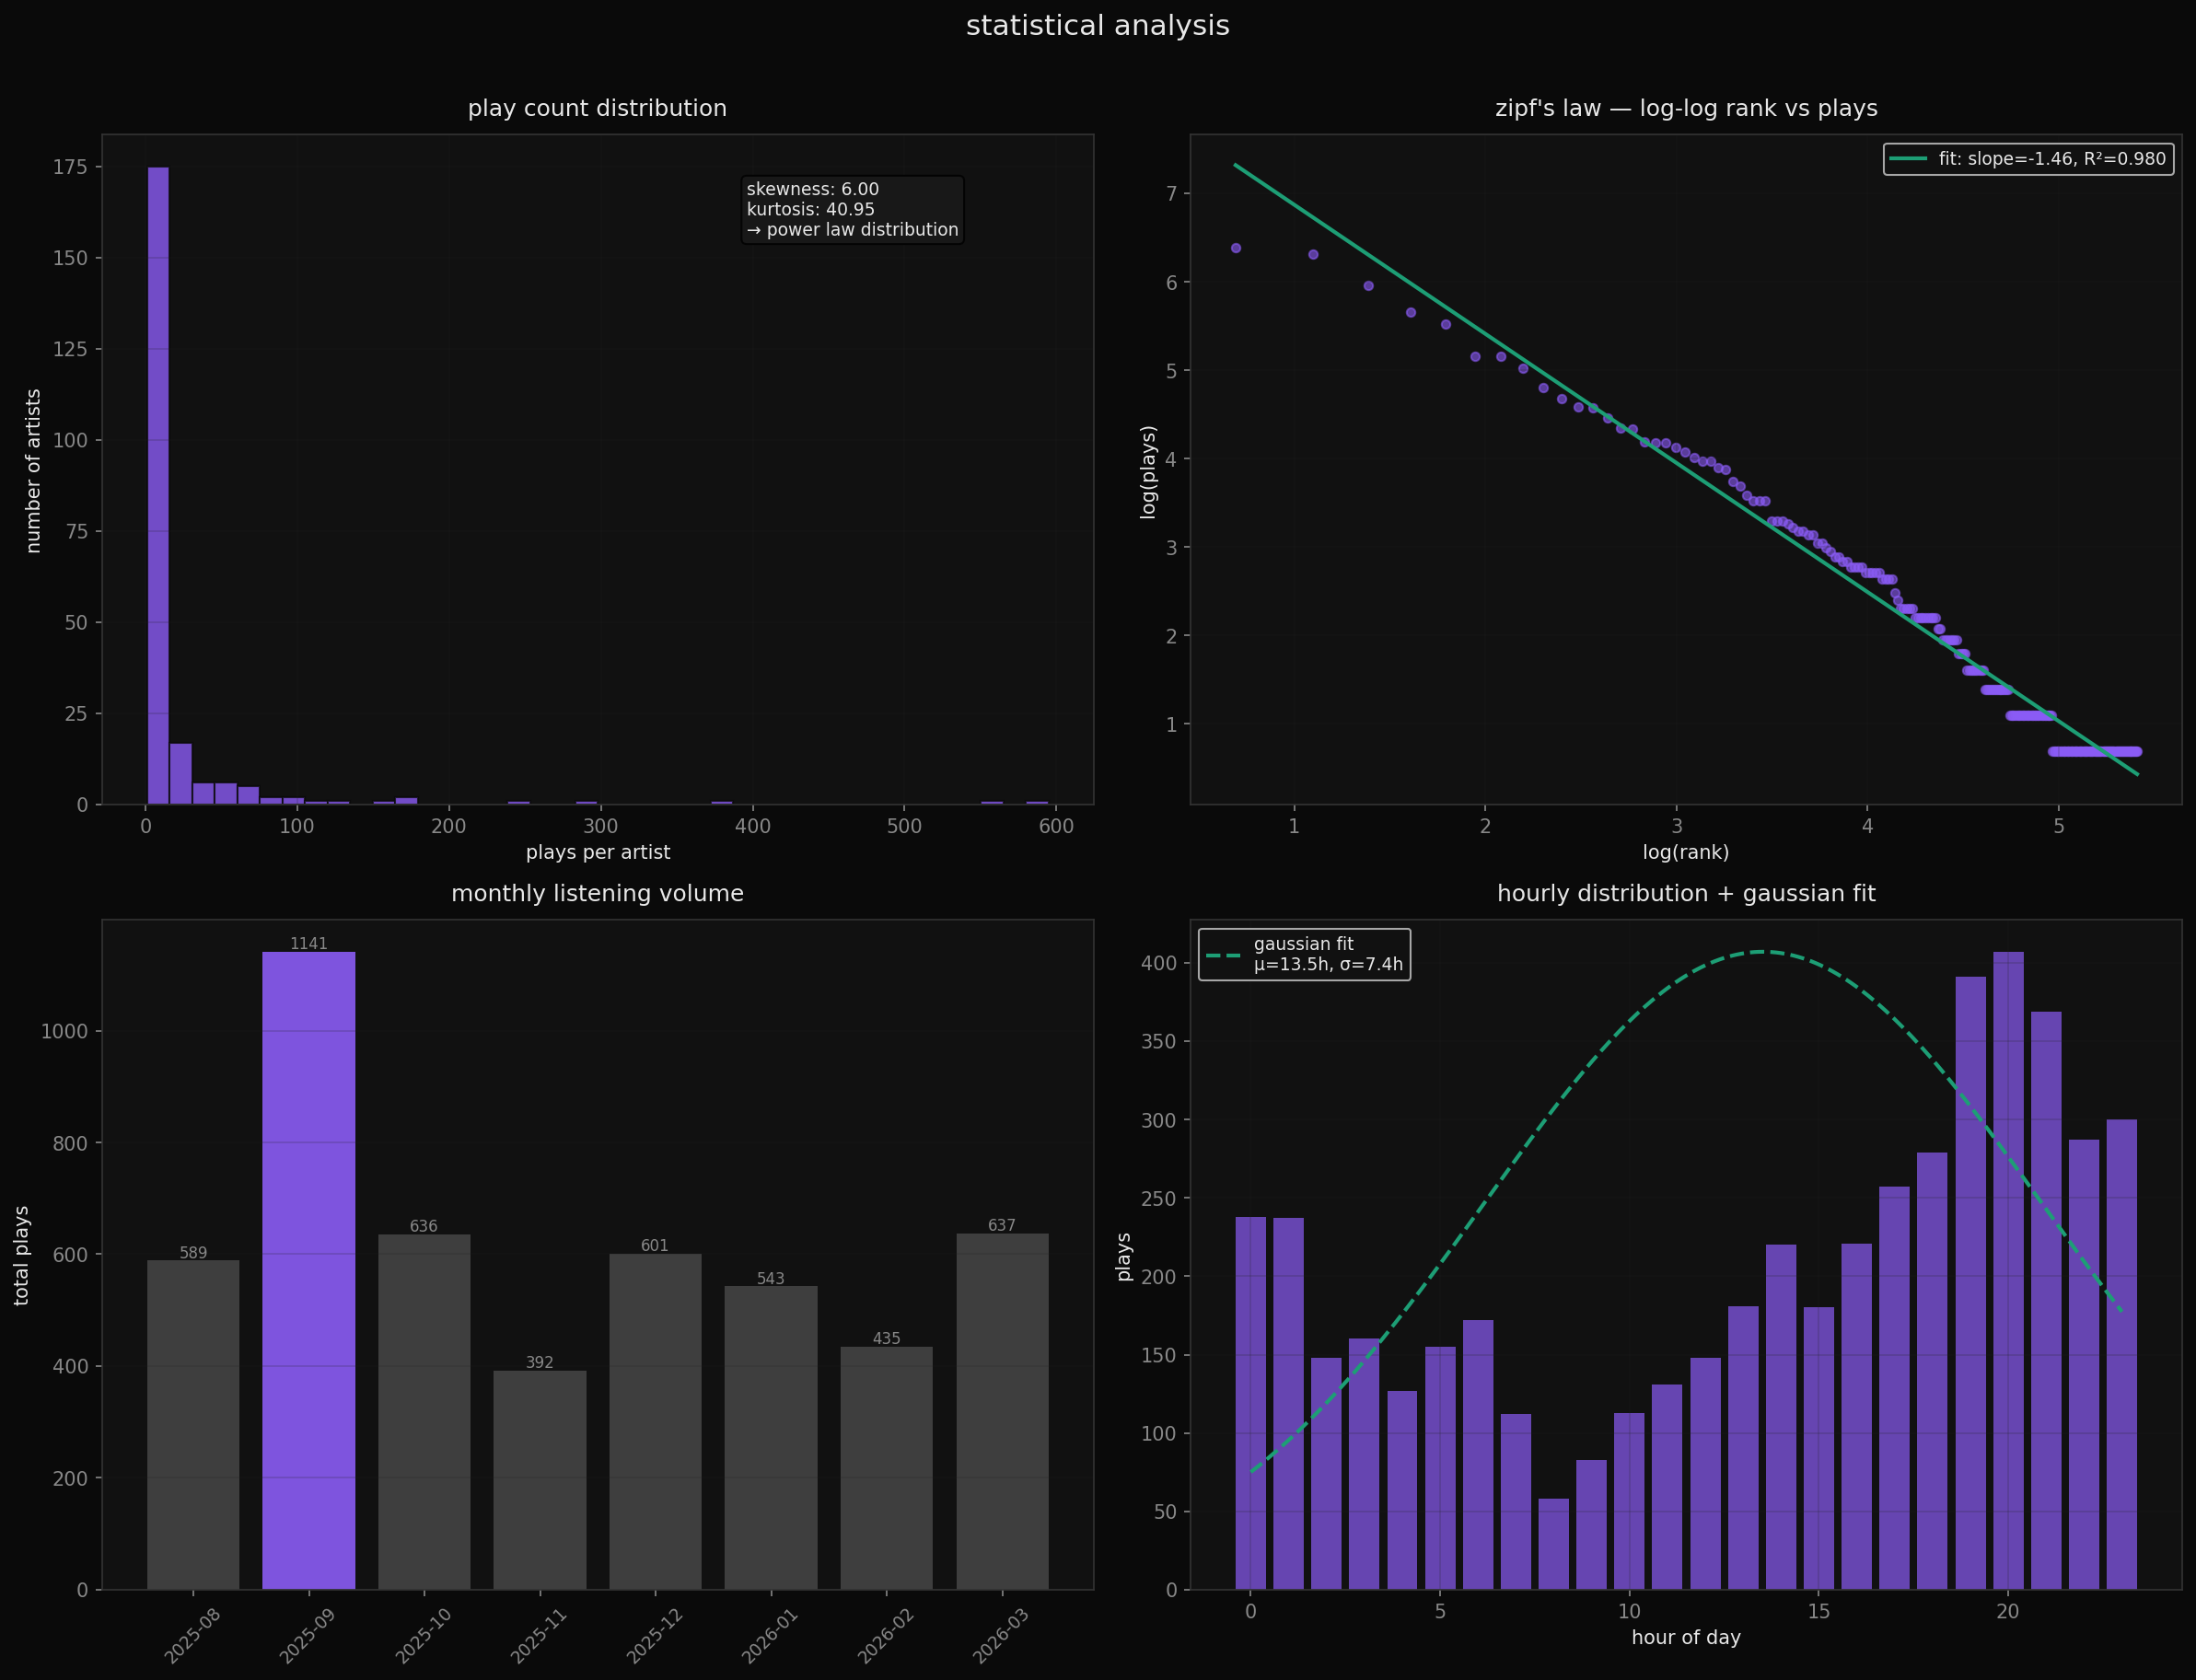

Statistical findings:
  Play count skewness:  6.00 (>1 = power law confirmed)
  Zipf R²:              0.980 (closer to 1 = stronger power law)
  Peak listening month: 2025-09
  Gaussian mean hour:   13.5 (13:00)
  Gaussian std:         7.4 hours


In [17]:
# ── PART 6: STATISTICAL ANALYSIS ─────────────────────────────
from scipy import stats

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ── 1. play count distribution (power law test) ───────────────
artist_plays_dist = history['artist'].value_counts()

axes[0,0].hist(artist_plays_dist.values, bins=40, 
               color=ACCENT, alpha=0.8, edgecolor='#0a0a0a')
axes[0,0].set_xlabel('plays per artist', fontsize=10)
axes[0,0].set_ylabel('number of artists', fontsize=10)
axes[0,0].set_title('play count distribution', fontsize=12, pad=10)
axes[0,0].grid(True, alpha=0.2)

# fit and annotate
skewness = stats.skew(artist_plays_dist.values)
kurtosis = stats.kurtosis(artist_plays_dist.values)
axes[0,0].text(0.65, 0.85,
    f'skewness: {skewness:.2f}\nkurtosis: {kurtosis:.2f}\n→ power law distribution',
    transform=axes[0,0].transAxes,
    color='#e8e8e8', fontsize=9,
    bbox=dict(boxstyle='round', facecolor='#1a1a1a', alpha=0.8))

# ── 2. log-log plot (confirms power law) ─────────────────────
log_plays = np.log1p(artist_plays_dist.values)
log_rank  = np.log1p(np.arange(1, len(artist_plays_dist) + 1))

axes[0,1].scatter(log_rank, log_plays, 
                  color=ACCENT, alpha=0.6, s=20)

# fit linear regression on log-log
slope, intercept, r, p, se = stats.linregress(log_rank, log_plays)
line = slope * log_rank + intercept
axes[0,1].plot(log_rank, line, color=ACCENT2, 
               linewidth=2, label=f'fit: slope={slope:.2f}, R²={r**2:.3f}')

axes[0,1].set_xlabel('log(rank)', fontsize=10)
axes[0,1].set_ylabel('log(plays)', fontsize=10)
axes[0,1].set_title("zipf's law — log-log rank vs plays", fontsize=12, pad=10)
axes[0,1].legend(fontsize=9)
axes[0,1].grid(True, alpha=0.2)

# ── 3. monthly listening volume ───────────────────────────────
monthly = history.groupby('month').size().reset_index(name='plays')
monthly = monthly.sort_values('month')

bar_colors_m = [ACCENT if i == monthly['plays'].idxmax() 
                else '#444444' for i in monthly.index]

axes[1,0].bar(range(len(monthly)), monthly['plays'], 
              color=bar_colors_m, alpha=0.9)
axes[1,0].set_xticks(range(len(monthly)))
axes[1,0].set_xticklabels(monthly['month'], rotation=45, fontsize=9)
axes[1,0].set_ylabel('total plays', fontsize=10)
axes[1,0].set_title('monthly listening volume', fontsize=12, pad=10)
axes[1,0].grid(True, alpha=0.2, axis='y')

# add value labels
for i, v in enumerate(monthly['plays']):
    axes[1,0].text(i, v + 5, str(v), ha='center', 
                  fontsize=8, color='#888888')

# ── 4. hourly distribution with gaussian fit ─────────────────
hourly_counts = history['hour'].value_counts().sort_index()

axes[1,1].bar(hourly_counts.index, hourly_counts.values,
              color=ACCENT, alpha=0.7, width=0.8)

# fit gaussian
x = hourly_counts.index.values
y = hourly_counts.values
mean_h = np.average(x, weights=y)
std_h  = np.sqrt(np.average((x - mean_h)**2, weights=y))

x_smooth = np.linspace(0, 23, 200)
gauss = np.exp(-0.5 * ((x_smooth - mean_h) / std_h)**2)
gauss = gauss * y.max()

axes[1,1].plot(x_smooth, gauss, color=ACCENT2, 
               linewidth=2, linestyle='--',
               label=f'gaussian fit\nμ={mean_h:.1f}h, σ={std_h:.1f}h')
axes[1,1].set_xlabel('hour of day', fontsize=10)
axes[1,1].set_ylabel('plays', fontsize=10)
axes[1,1].set_title('hourly distribution + gaussian fit', fontsize=12, pad=10)
axes[1,1].legend(fontsize=9)
axes[1,1].grid(True, alpha=0.2)

plt.suptitle('statistical analysis', fontsize=15, y=1.01, color='#e8e8e8')
plt.tight_layout()
plt.savefig('/Users/saturnine/echoes/data/viz_stats.png',
            dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

print("Statistical findings:")
print(f"  Play count skewness:  {skewness:.2f} (>1 = power law confirmed)")
print(f"  Zipf R²:              {r**2:.3f} (closer to 1 = stronger power law)")
print(f"  Peak listening month: {monthly.loc[monthly['plays'].idxmax(), 'month']}")
print(f"  Gaussian mean hour:   {mean_h:.1f} ({int(mean_h):02d}:00)")
print(f"  Gaussian std:         {std_h:.1f} hours")

Matrix: (48, 80)
Artists: 48


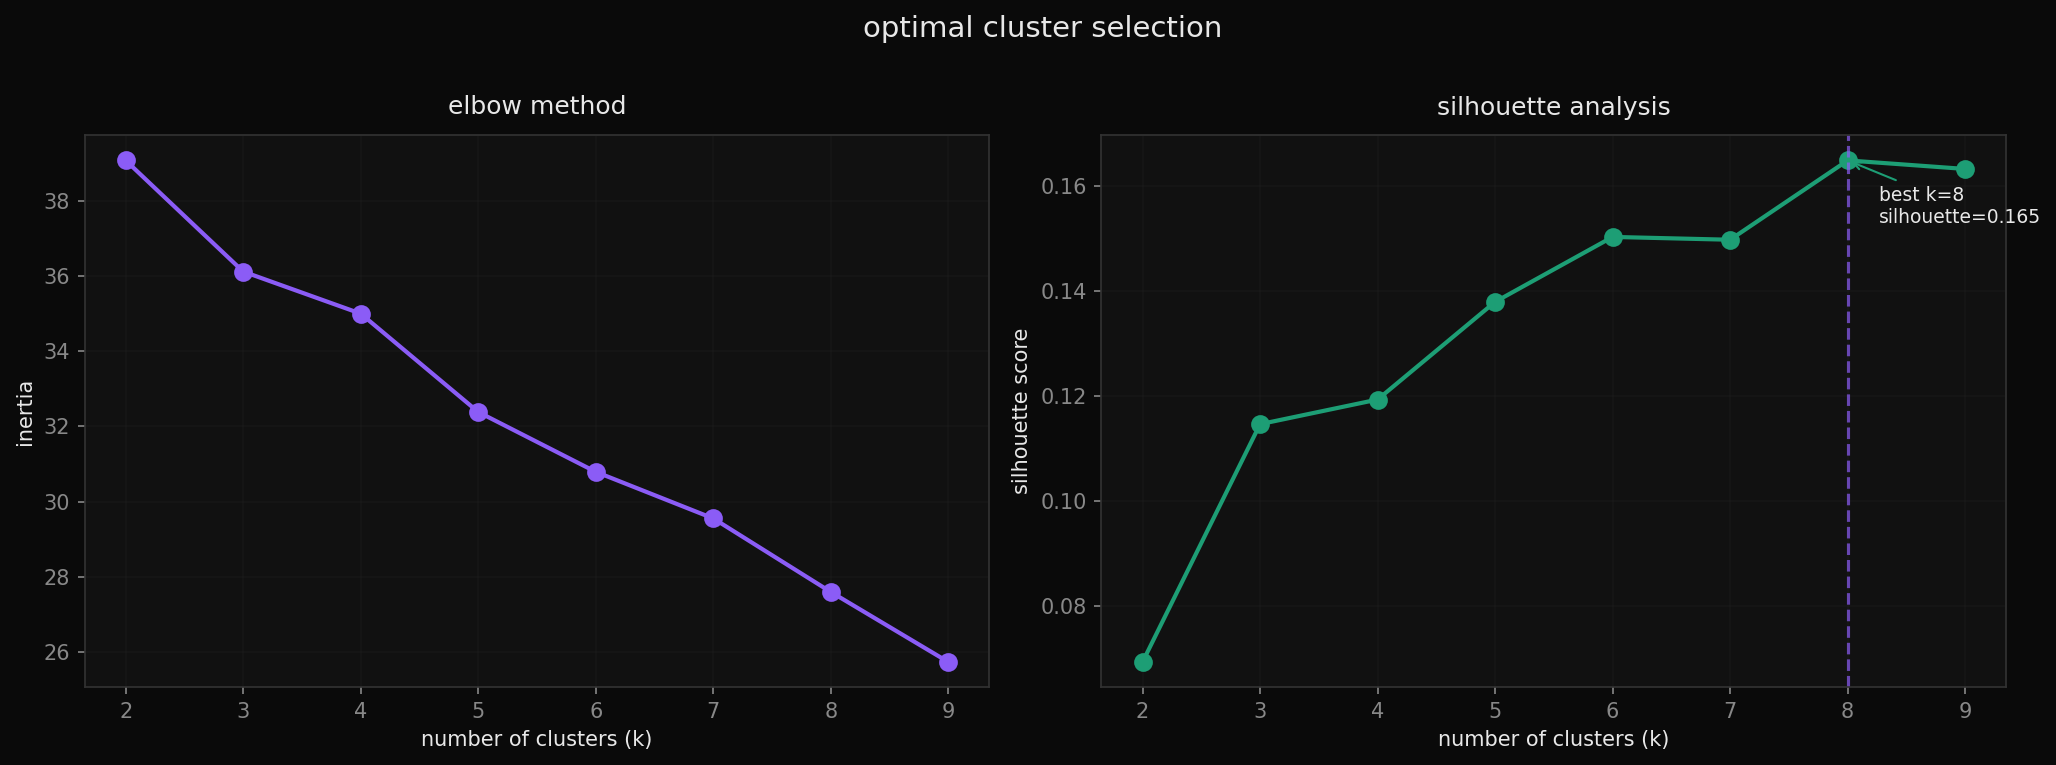


Best k by silhouette: 8
Silhouette scores: ['0.069', '0.115', '0.119', '0.138', '0.150', '0.150', '0.165', '0.163']


In [18]:
# ── PART 7: CLUSTERING ────────────────────────────────────────
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
import json

# load clean matrix
matrix_norm  = np.load('/Users/saturnine/echoes/data/tfidf_final.npy')
with open('/Users/saturnine/echoes/data/artists_final.json') as f:
    artists_final = json.load(f)

print(f"Matrix: {matrix_norm.shape}")
print(f"Artists: {len(artists_final)}")

# ── find optimal k using elbow + silhouette ───────────────────
inertias    = []
silhouettes = []
k_range     = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(matrix_norm)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(matrix_norm, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, color=ACCENT, 
             linewidth=2, marker='o', markersize=8)
axes[0].set_xlabel('number of clusters (k)', fontsize=10)
axes[0].set_ylabel('inertia', fontsize=10)
axes[0].set_title('elbow method', fontsize=12, pad=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_range, silhouettes, color=ACCENT2,
             linewidth=2, marker='o', markersize=8)
best_k = k_range[np.argmax(silhouettes)]
axes[1].axvline(best_k, color=ACCENT, linestyle='--', alpha=0.7)
axes[1].annotate(f'best k={best_k}\nsilhouette={max(silhouettes):.3f}',
                xy=(best_k, max(silhouettes)),
                xytext=(15, -30), textcoords='offset points',
                color='#e8e8e8', fontsize=9,
                arrowprops=dict(arrowstyle='->', color=ACCENT2))
axes[1].set_xlabel('number of clusters (k)', fontsize=10)
axes[1].set_ylabel('silhouette score', fontsize=10)
axes[1].set_title('silhouette analysis', fontsize=12, pad=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('optimal cluster selection', fontsize=14, 
             y=1.01, color='#e8e8e8')
plt.tight_layout()
plt.savefig('/Users/saturnine/echoes/data/viz_elbow.png',
            dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

print(f"\nBest k by silhouette: {best_k}")
print(f"Silhouette scores: {[f'{s:.3f}' for s in silhouettes]}")

PCA variance explained (10 components): 53.5%
t-SNE done


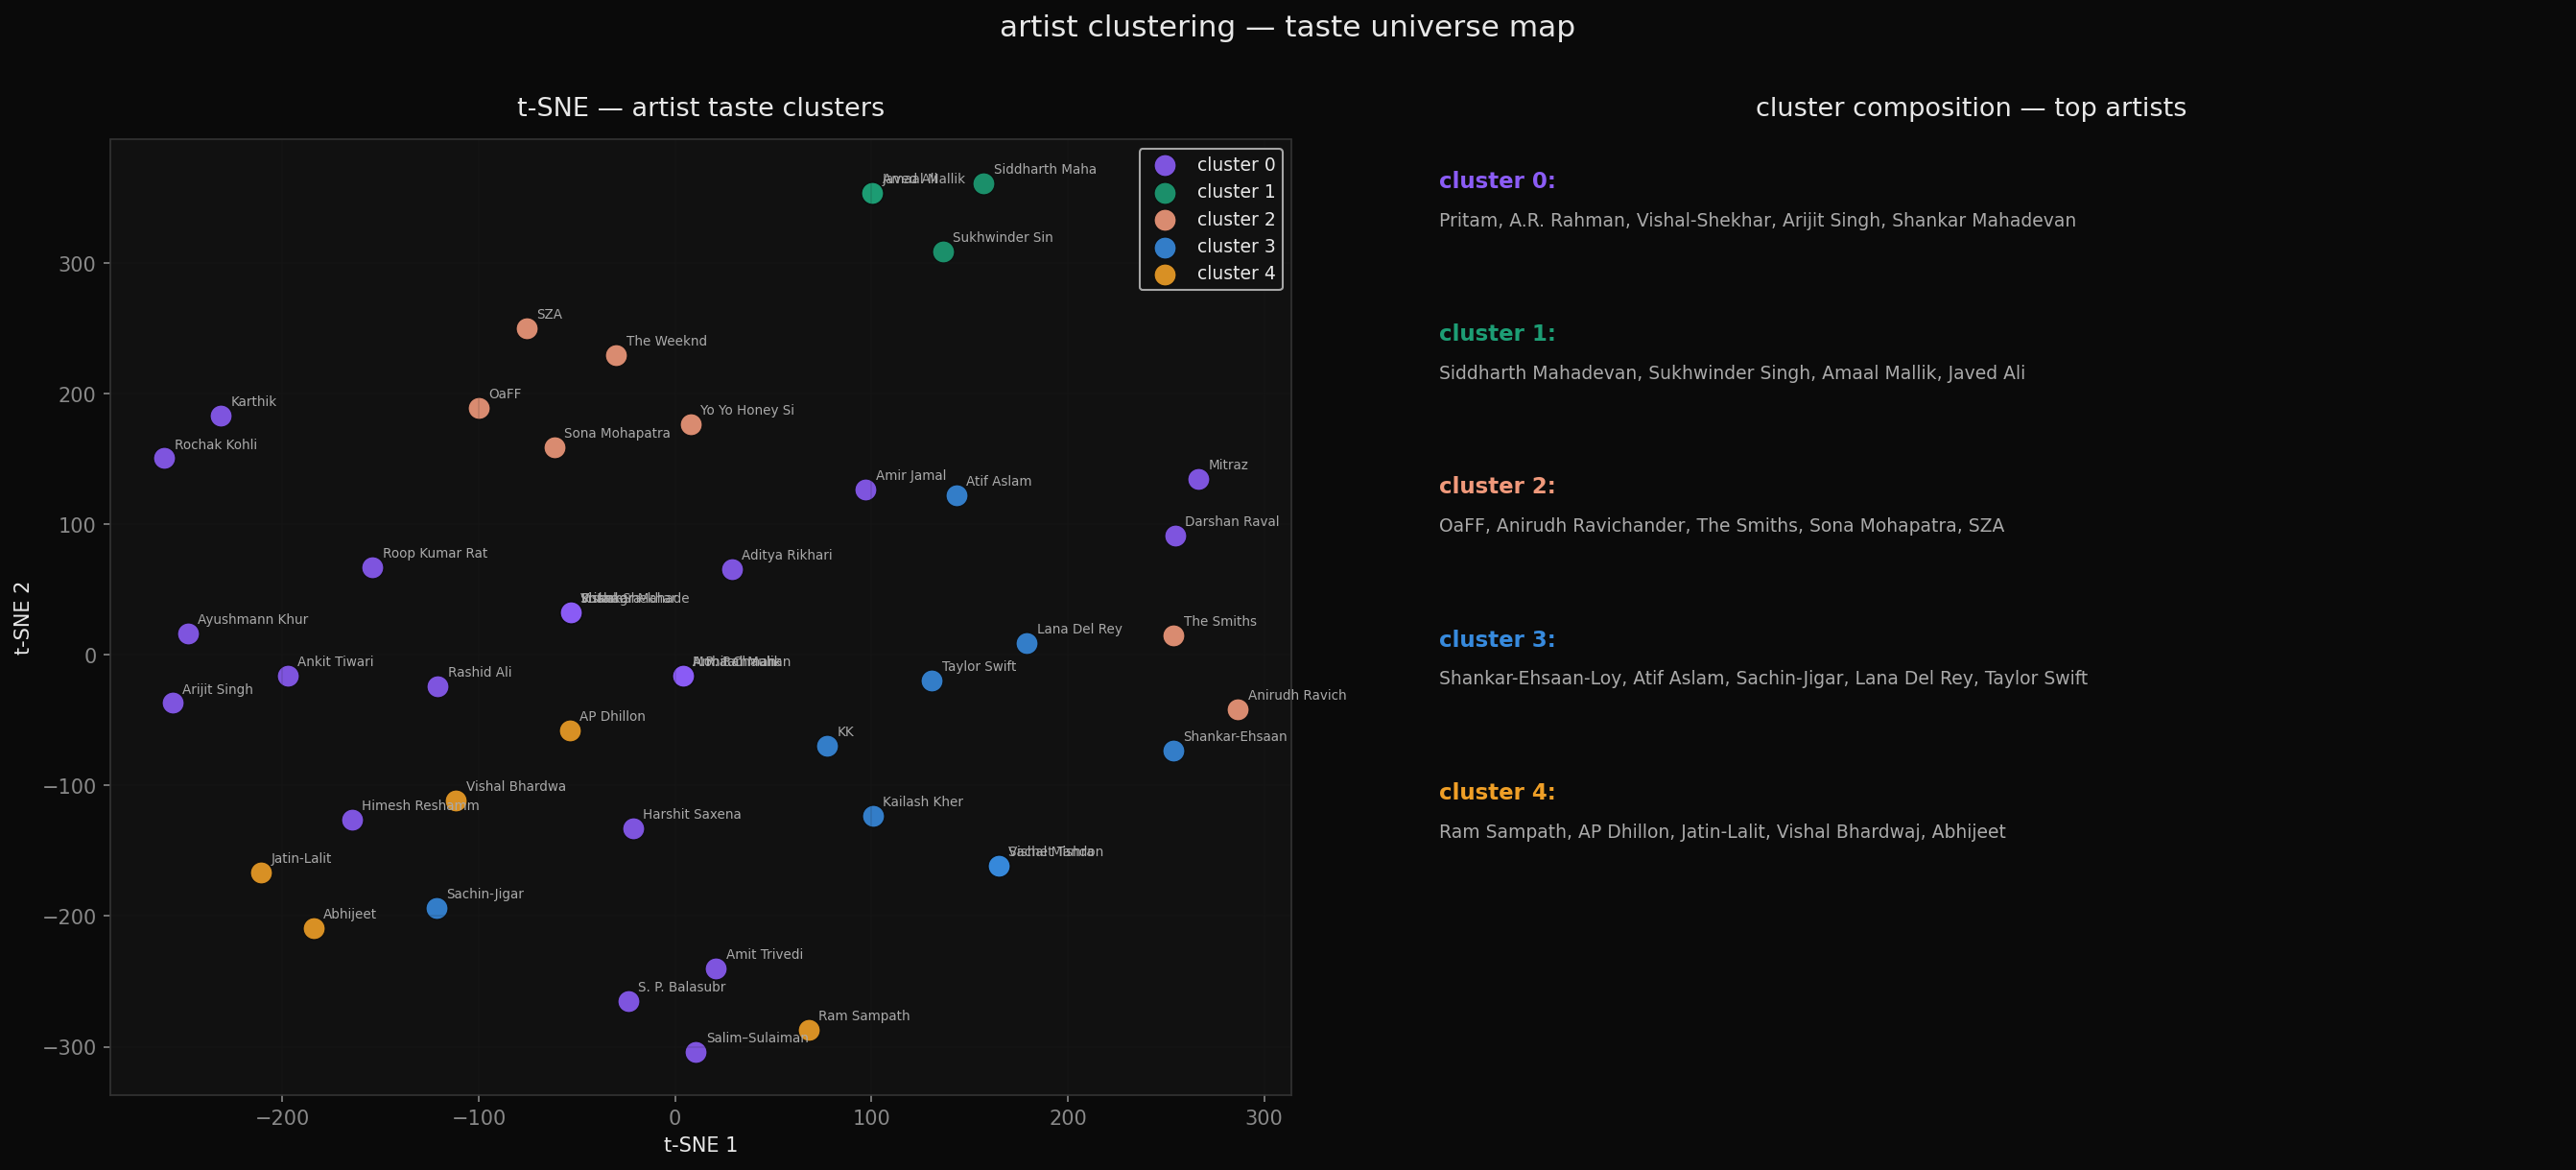


Full cluster breakdown:

Cluster 0 (23 artists):
  Pritam                     595 plays  ['pritam']
  A.R. Rahman                387 plays  ['instrumental']
  Vishal-Shekhar             250 plays  ['dance', 'happy']
  Arijit Singh               172 plays  ['indipop', 'romantic', 'melody']
  Shankar Mahadevan           75 plays  ['shankar mahadevan', 'shankar', 'shankar ehsaan loy']
  Mohit Chauhan               65 plays  ['enrique']
  Ayushmann Khurrana          58 plays  ['world music', 'soothing', 'romantic', 'groove']
  Himesh Reshammiya           54 plays  ['indian music director', 'himesh', 'bollywood soundtrack']
  Aditya Rikhari              52 plays  ['hindie']
  Amir Jamal                  52 plays  ['pakistani']
  Amit Trivedi                48 plays  ['indian fusion', 'dev d', 'amit trivedi', 'udaan']
  Roop Kumar Rathod           41 plays  ['vocals', 'classical', 'asian', 'sufi']
  S. P. Balasubrahmanyam      26 plays  ['chillout', 'ambient', 'melodious', 'golden']
  Rocha

In [20]:
# ── fit final k=5 clusters ────────────────────────────────────
K = 5
km_final = KMeans(n_clusters=K, random_state=42, n_init=20)
cluster_labels = km_final.fit_predict(matrix_norm)

# ── PCA to 2D first ───────────────────────────────────────────
pca = PCA(n_components=10, random_state=42)
reduced_pca = pca.fit_transform(matrix_norm)
print(f"PCA variance explained (10 components): "
      f"{pca.explained_variance_ratio_.sum():.1%}")

# ── t-SNE to 2D ───────────────────────────────────────────────
tsne = TSNE(
    n_components=2,
    perplexity=15,
    random_state=42,
    max_iter=1000,      # fixed: was n_iter
    learning_rate='auto',
    init='pca'
)
reduced_tsne = tsne.fit_transform(reduced_pca)
print("t-SNE done")

# ── cluster color map ─────────────────────────────────────────
cluster_colors = [ACCENT, ACCENT2, ACCENT3, '#378ADD', '#EF9F27']

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# ── left: t-SNE colored by cluster ───────────────────────────
for c in range(K):
    mask = cluster_labels == c
    axes[0].scatter(
        reduced_tsne[mask, 0],
        reduced_tsne[mask, 1],
        color=cluster_colors[c],
        s=120, alpha=0.9,
        label=f'cluster {c}',
        edgecolors='#0a0a0a', linewidth=0.5
    )

for i, artist in enumerate(artists_final):
    axes[0].annotate(
        artist[:14],
        (reduced_tsne[i, 0], reduced_tsne[i, 1]),
        fontsize=6.5, color='#aaaaaa',
        xytext=(5, 5), textcoords='offset points'
    )

axes[0].set_title('t-SNE — artist taste clusters', fontsize=13, pad=12)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.15)
axes[0].set_xlabel('t-SNE 1', fontsize=10)
axes[0].set_ylabel('t-SNE 2', fontsize=10)

# ── right: cluster composition ───────────────────────────────
artist_play_map    = history['artist'].value_counts().to_dict()
cluster_artist_map = {}
for c in range(K):
    cluster_artist_map[c] = [artists_final[i]
                              for i in range(len(artists_final))
                              if cluster_labels[i] == c]

y_pos = 0.95
for c in range(K):
    top_in_c = sorted(cluster_artist_map[c],
                      key=lambda a: artist_play_map.get(a, 0),
                      reverse=True)[:5]
    axes[1].text(0.05, y_pos, f'cluster {c}:',
                fontsize=11, fontweight='bold',
                color=cluster_colors[c],
                transform=axes[1].transAxes)
    axes[1].text(0.05, y_pos - 0.04,
                ', '.join(top_in_c),
                fontsize=9, color='#aaaaaa',
                transform=axes[1].transAxes)
    y_pos -= 0.16

axes[1].axis('off')
axes[1].set_title('cluster composition — top artists',
                  fontsize=13, pad=12)

plt.suptitle('artist clustering — taste universe map',
             fontsize=15, y=1.01, color='#e8e8e8')
plt.tight_layout()
plt.savefig('/Users/saturnine/echoes/data/viz_clusters.png',
            dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

# print full cluster breakdown
print("\nFull cluster breakdown:")
for c in range(K):
    top = sorted(cluster_artist_map[c],
                key=lambda a: artist_play_map.get(a, 0),
                reverse=True)
    print(f"\nCluster {c} ({len(cluster_artist_map[c])} artists):")
    for a in top:
        tags = artist_tags_final.get(a, [])[:4]
        print(f"  {a:<25} {artist_play_map.get(a,0):>4} plays  {tags}")

✓ Clusters saved


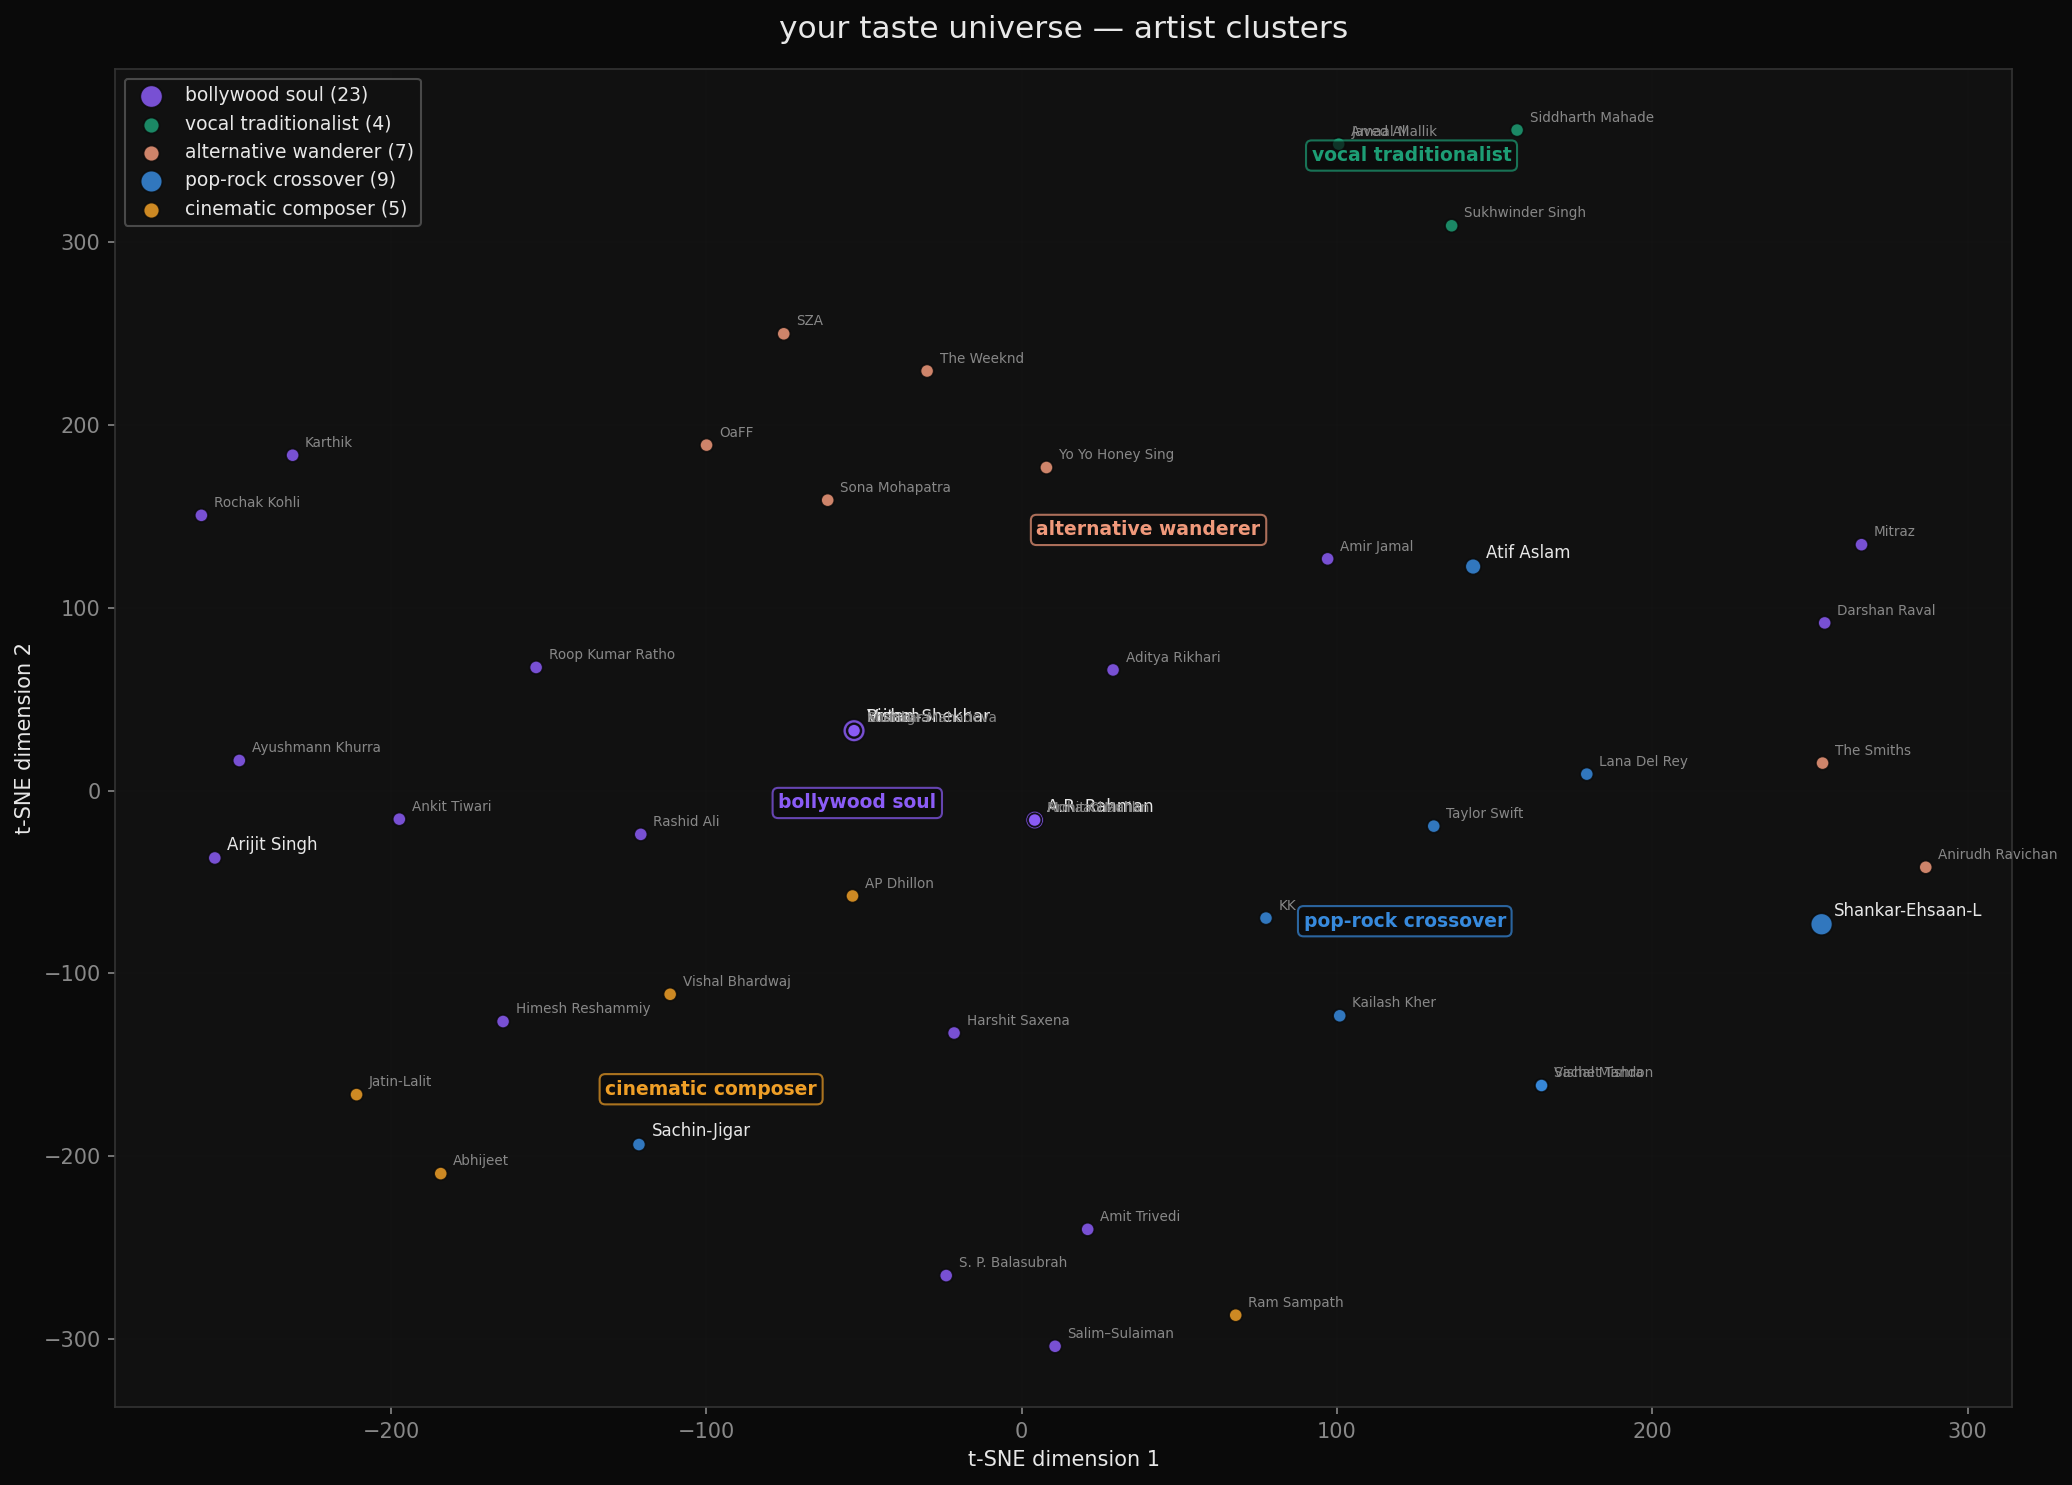


Your taste universe:

  BOLLYWOOD SOUL
  cinematic indian scores, melodic bollywood, emotional depth
  23 artists · 2042 plays

  VOCAL TRADITIONALIST
  classical playback tradition, pure vocal artistry
  4 artists · 95 plays

  ALTERNATIVE WANDERER
  western indie, rnb, electronic, post-punk — the moody lane
  7 artists · 226 plays

  POP-ROCK CROSSOVER
  guitar-driven pop-rock bridging east and west
  9 artists · 1148 plays

  CINEMATIC COMPOSER
  film composers, fusion, cinematic storytelling
  5 artists · 136 plays


In [21]:
# ── named archetypes based on cluster analysis ────────────────
CLUSTER_NAMES = {
    0: "bollywood soul",
    1: "vocal traditionalist", 
    2: "alternative wanderer",
    3: "pop-rock crossover",
    4: "cinematic composer",
}

CLUSTER_DESCRIPTIONS = {
    0: "cinematic indian scores, melodic bollywood, emotional depth",
    1: "classical playback tradition, pure vocal artistry",
    2: "western indie, rnb, electronic, post-punk — the moody lane",
    3: "guitar-driven pop-rock bridging east and west",
    4: "film composers, fusion, cinematic storytelling",
}

# save cluster assignments
cluster_df = pd.DataFrame({
    'artist':       artists_final,
    'cluster':      cluster_labels,
    'cluster_name': [CLUSTER_NAMES[c] for c in cluster_labels],
    'plays':        [artist_play_map.get(a, 0) for a in artists_final],
})
cluster_df = cluster_df.sort_values('plays', ascending=False)
cluster_df.to_csv('/Users/saturnine/echoes/data/artist_clusters.csv', index=False)
print("✓ Clusters saved")

# ── final visualization ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 10))

for c in range(K):
    mask = cluster_labels == c
    ax.scatter(
        reduced_tsne[mask, 0],
        reduced_tsne[mask, 1],
        color=cluster_colors[c],
        s=[max(40, artist_play_map.get(artists_final[i], 0) / 5) 
           for i in range(len(artists_final)) if mask[i]],
        alpha=0.85,
        label=f'{CLUSTER_NAMES[c]} ({mask.sum()})',
        edgecolors='#0a0a0a', linewidth=0.8,
        zorder=3
    )

# label artists — size by plays
for i, artist in enumerate(artists_final):
    plays = artist_play_map.get(artist, 0)
    fontsize = 8 if plays > 100 else 6.5
    color    = '#e8e8e8' if plays > 100 else '#888888'
    ax.annotate(
        artist[:16],
        (reduced_tsne[i, 0], reduced_tsne[i, 1]),
        fontsize=fontsize, color=color,
        xytext=(6, 4), textcoords='offset points',
        zorder=4
    )

ax.set_title('your taste universe — artist clusters', 
             fontsize=15, pad=15, color='#e8e8e8')
ax.legend(fontsize=9, markerscale=1.2, 
          loc='upper left', framealpha=0.3)
ax.grid(True, alpha=0.12)
ax.set_xlabel('t-SNE dimension 1', fontsize=10)
ax.set_ylabel('t-SNE dimension 2', fontsize=10)

# add cluster label annotations in center of each cluster
for c in range(K):
    mask = cluster_labels == c
    cx = reduced_tsne[mask, 0].mean()
    cy = reduced_tsne[mask, 1].mean()
    ax.text(cx, cy, CLUSTER_NAMES[c],
            fontsize=9, color=cluster_colors[c],
            ha='center', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', 
                     facecolor='#0a0a0a', 
                     alpha=0.7, edgecolor=cluster_colors[c]),
            zorder=5)

plt.tight_layout()
plt.savefig('/Users/saturnine/echoes/data/viz_tsne_final.png',
            dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

print("\nYour taste universe:")
for c in range(K):
    artists_c = cluster_df[cluster_df['cluster'] == c]
    total_plays = artists_c['plays'].sum()
    print(f"\n  {CLUSTER_NAMES[c].upper()}")
    print(f"  {CLUSTER_DESCRIPTIONS[c]}")
    print(f"  {len(artists_c)} artists · {total_plays} plays")

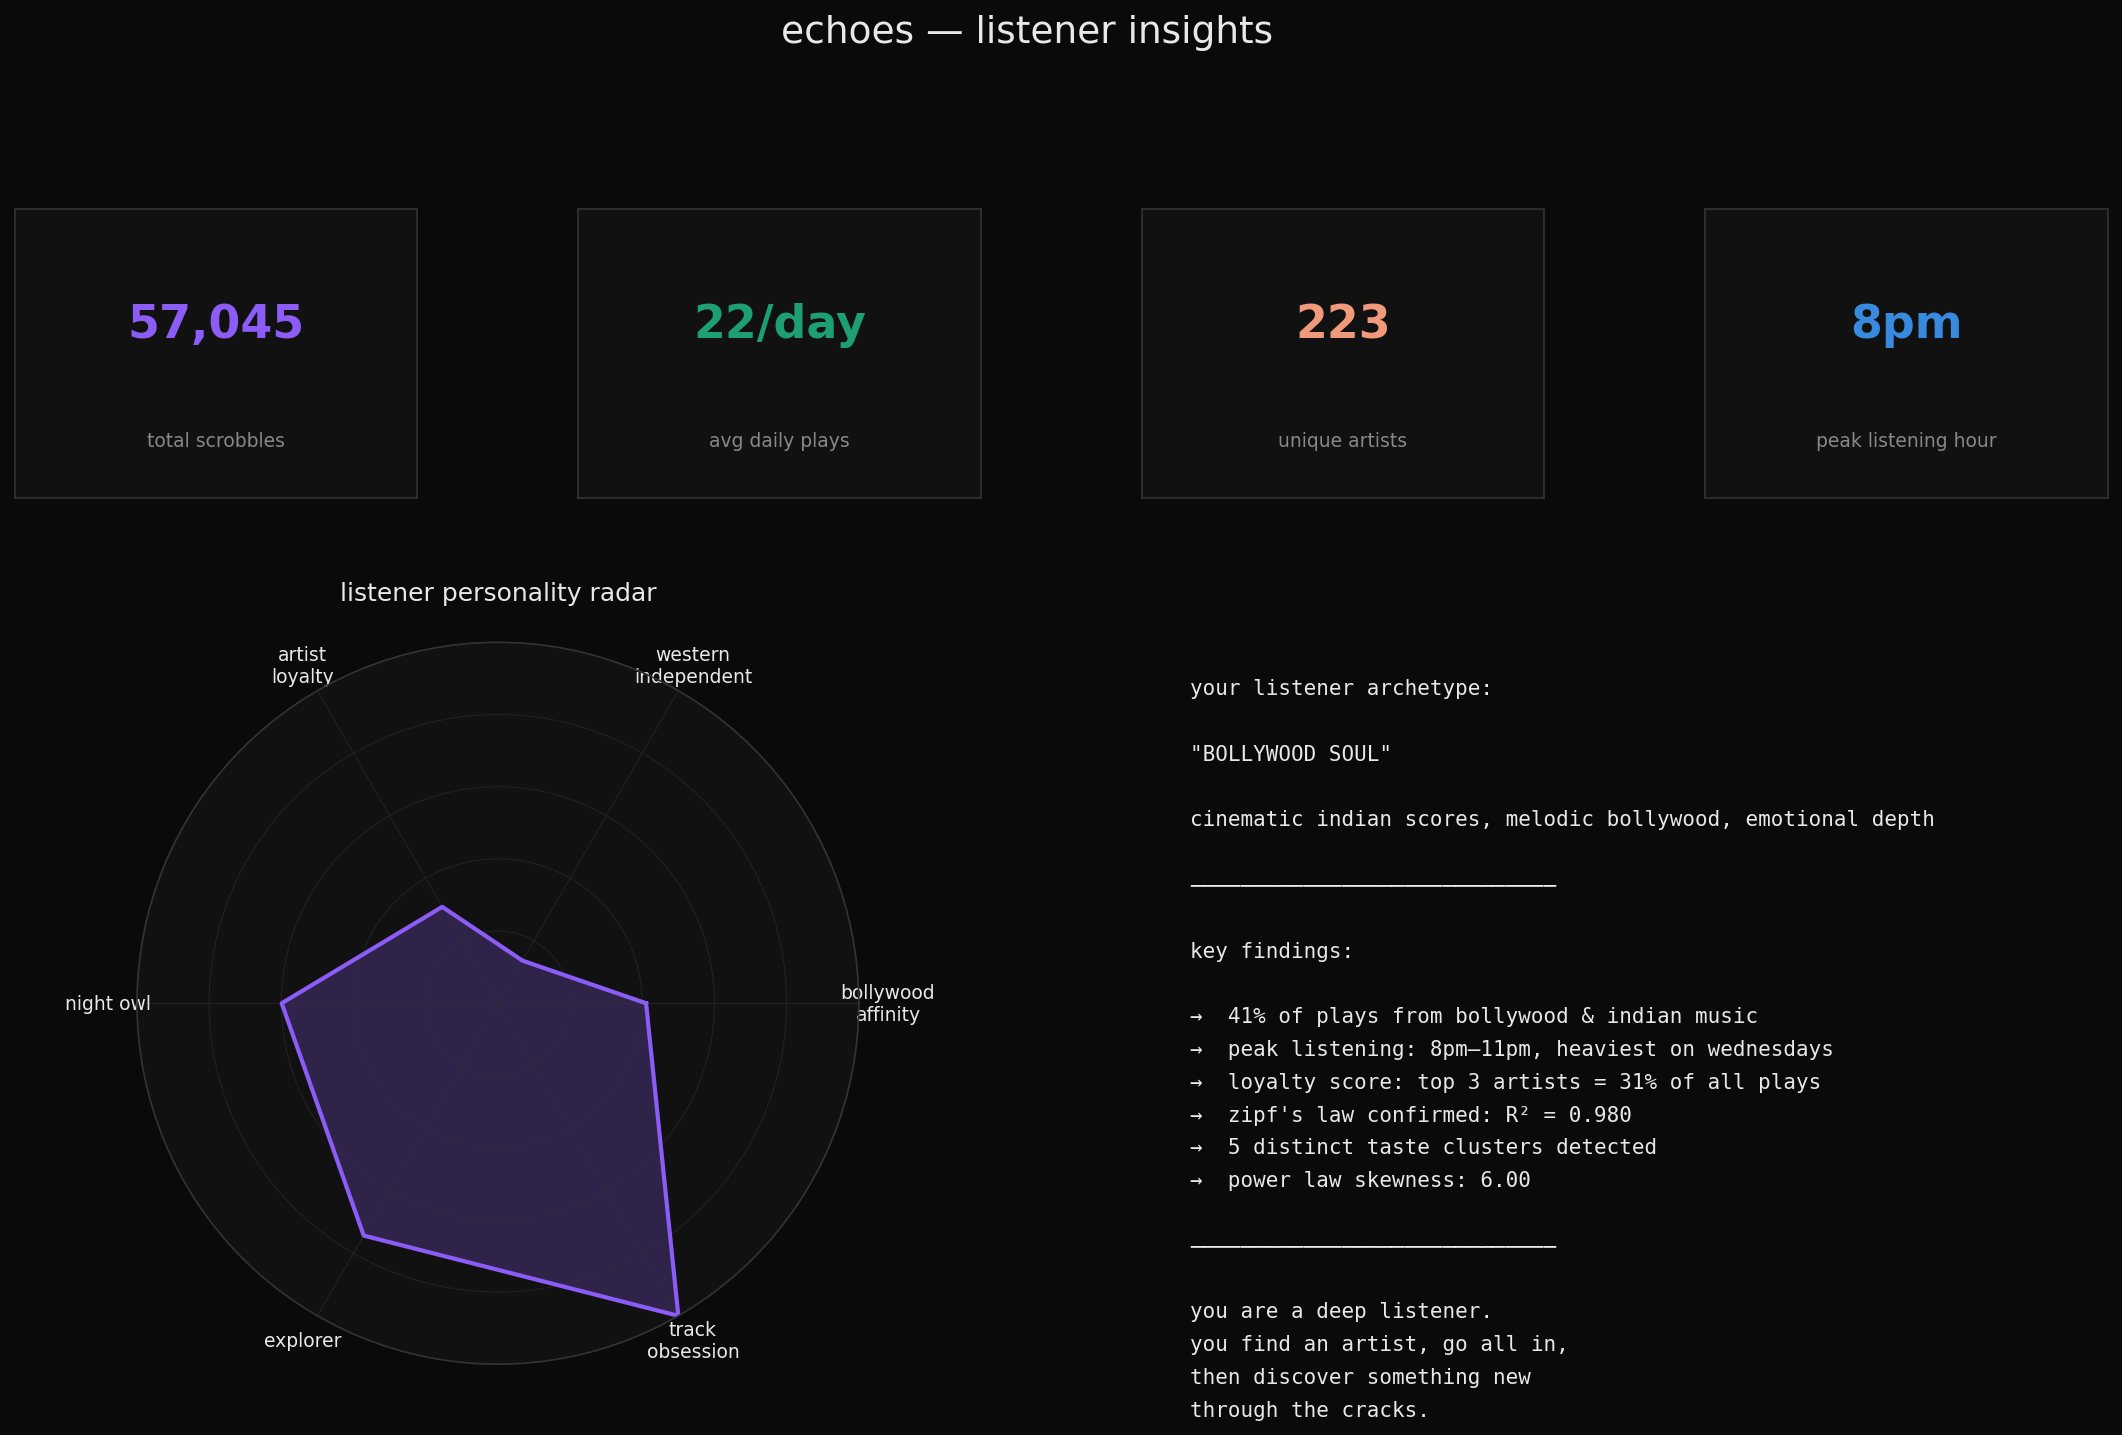

✓ Insights dashboard saved


In [22]:
# ── PART 8: INSIGHTS SUMMARY ─────────────────────────────────

fig = plt.figure(figsize=(18, 10))

# custom grid layout
gs = fig.add_gridspec(3, 4, hspace=0.5, wspace=0.4)

ax_stat1 = fig.add_subplot(gs[0, 0])
ax_stat2 = fig.add_subplot(gs[0, 1])
ax_stat3 = fig.add_subplot(gs[0, 2])
ax_stat4 = fig.add_subplot(gs[0, 3])
ax_radar = fig.add_subplot(gs[1:, :2], polar=True)
ax_text  = fig.add_subplot(gs[1:, 2:])

# ── stat cards ────────────────────────────────────────────────
def stat_card(ax, value, label, color=ACCENT):
    ax.set_facecolor('#111111')
    ax.text(0.5, 0.6, value, transform=ax.transAxes,
            ha='center', va='center',
            fontsize=22, fontweight='bold', color=color)
    ax.text(0.5, 0.2, label, transform=ax.transAxes,
            ha='center', va='center',
            fontsize=9, color='#888888')
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor('#333333')

stat_card(ax_stat1, f"{info['playcount']:,}", "total scrobbles", ACCENT)
stat_card(ax_stat2, "22/day", "avg daily plays", ACCENT2)
stat_card(ax_stat3, f"{history['artist'].nunique()}", "unique artists", ACCENT3)
stat_card(ax_stat4, "8pm", "peak listening hour", '#378ADD')

# ── radar chart — listener personality ───────────────────────
# compute 6 personality dimensions from data
total_plays = len(history)

# 1. bollywood affinity (% of plays from bollywood cluster)
bollywood_artists = cluster_df[cluster_df['cluster'] == 0]['artist'].tolist()
bollywood_plays   = history[history['artist'].isin(bollywood_artists)].shape[0]
bollywood_score   = bollywood_plays / total_plays

# 2. western indie affinity
western_artists = cluster_df[cluster_df['cluster'] == 2]['artist'].tolist()
western_plays   = history[history['artist'].isin(western_artists)].shape[0]
western_score   = western_plays / total_plays * 3  # amplify for visibility

# 3. loyalty score (how concentrated are plays)
top3_plays   = history['artist'].value_counts().head(3).sum()
loyalty_score = top3_plays / total_plays

# 4. night owl score
night_plays  = history[history['hour'].isin(range(20, 24))].shape[0]
night_plays += history[history['hour'].isin(range(0, 3))].shape[0]
night_score  = night_plays / total_plays * 1.5

# 5. exploration score (unique artists / total plays normalized)
exploration_score = min(history['artist'].nunique() / 300, 1.0)

# 6. obsession score (max single track plays / total)
max_track_plays = history.groupby('title').size().max()
obsession_score = min(max_track_plays / 50, 1.0)

categories = ['bollywood\naffinity', 'western\nindependent', 
              'artist\nloyalty', 'night owl', 
              'explorer', 'track\nobsession']
values = [bollywood_score, western_score, loyalty_score,
          night_score, exploration_score, obsession_score]
values = [min(v, 1.0) for v in values]

# close the radar
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
values_plot = values + values[:1]

ax_radar.plot(angles, values_plot, color=ACCENT, linewidth=2)
ax_radar.fill(angles, values_plot, color=ACCENT, alpha=0.25)
ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(categories, fontsize=9, color='#e8e8e8')
ax_radar.set_ylim(0, 1)
ax_radar.set_facecolor('#111111')
ax_radar.grid(color='#333333', linewidth=0.5)
ax_radar.spines['polar'].set_color('#333333')
ax_radar.set_yticklabels([])
ax_radar.set_title('listener personality radar', 
                   fontsize=12, pad=20, color='#e8e8e8')

# ── personality text panel ────────────────────────────────────
ax_text.set_facecolor('#111111')
ax_text.axis('off')

# determine dominant archetype
dominant_cluster = cluster_df.groupby('cluster')['plays'].sum().idxmax()
dominant_name    = CLUSTER_NAMES[dominant_cluster]
dominant_desc    = CLUSTER_DESCRIPTIONS[dominant_cluster]

# personality paragraph
night_pct    = f"{night_score/1.5*100:.0f}%"
loyalty_pct  = f"{loyalty_score*100:.0f}%"
bollywood_pct = f"{bollywood_score*100:.0f}%"

personality_text = f"""your listener archetype:

"{dominant_name.upper()}"

{dominant_desc}

─────────────────────────────

key findings:

→  {bollywood_pct} of plays from bollywood & indian music
→  peak listening: 8pm–11pm, heaviest on wednesdays  
→  loyalty score: top 3 artists = {loyalty_pct} of all plays
→  zipf's law confirmed: R² = 0.980
→  5 distinct taste clusters detected
→  power law skewness: 6.00

─────────────────────────────

you are a deep listener.
you find an artist, go all in,
then discover something new
through the cracks."""

ax_text.text(0.05, 0.95, personality_text,
            transform=ax_text.transAxes,
            fontsize=10, color='#e8e8e8',
            verticalalignment='top',
            fontfamily='monospace',
            linespacing=1.8)

for spine in ax_text.spines.values():
    spine.set_edgecolor('#333333')

fig.patch.set_facecolor('#0a0a0a')
fig.suptitle('echoes — listener insights', 
             fontsize=18, color='#e8e8e8', y=1.01)

plt.savefig('/Users/saturnine/echoes/data/viz_insights.png',
            dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()
print("✓ Insights dashboard saved")